# Medical MNIST - Comprehensive Debugging & Analysis

This notebook provides advanced debugging, error analysis, and medical-specific insights for the Medical MNIST classification pipeline.

**Features:**
- Data quality debugging
- Wrong prediction analysis
- Grad-CAM visualization for model interpretability
- Medical-specific metrics and analysis
- Per-class performance analysis
- Confusion matrix deep dive

In [52]:
!git clone https://github.com/VinyVan/MedicalMNIST.git
%cd MedicalMNIST

Cloning into 'MedicalMNIST'...
remote: Enumerating objects: 76, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 76 (delta 0), reused 3 (delta 0), pack-reused 70 (from 1)
Receiving objects: 100% (76/76), 137.32 MiB | 29.63 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/MedicalMNIST/MedicalMNIST


In [53]:
!git checkout feature/initial-medical-mnist-pipeline
!git pull origin feature/initial-medical-mnist-pipeline


Updating files: 100% (8/8), done.
Branch 'feature/initial-medical-mnist-pipeline' set up to track remote branch 'feature/initial-medical-mnist-pipeline' from 'origin'.
Switched to a new branch 'feature/initial-medical-mnist-pipeline'
From https://github.com/VinyVan/MedicalMNIST
 * branch            feature/initial-medical-mnist-pipeline -> FETCH_HEAD
Already up to date.


In [54]:
!python download_data.py

Medical MNIST Data Download

  /content/MedicalMNIST/MedicalMNIST/data/raw

This may take a few minutes depending on your connection...
------------------------------------------------------------
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/medical-mnist
100% 84.8M/84.8M [00:00<00:00, 223MB/s]


Download complete!

Data verified successfully!
You can now run: python main.py --running_mode debug


In [55]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import cv2
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('../src')

# Import project modules
from config.config import Config
from config.paths import Paths
from src.data_loader import load_medical_mnist_data, create_data_loaders, check_data_exists
from src.modeling.models import get_model
from src.training.trainer import CVTrainer
from src.utils import set_seed, get_device

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Setup complete!")

Setup complete!


In [56]:
import os

# Set Kaggle credentials from environment variables
os.environ["KAGGLE_USERNAME"] = "vinymo"
os.environ["KAGGLE_KEY"] = "46444c4168069d3d6e2d1dc63f12884a"

print("Kaggle credentials configured!")
print(f"Username: {os.environ["KAGGLE_USERNAME"]}")

Kaggle credentials configured!
Username: vinymo


In [57]:
!python download_data.py

Medical MNIST Data Download

Data already exists in: /content/MedicalMNIST/MedicalMNIST/data/raw
Skipping download.


In [58]:
torch.cuda.is_available()

True

## 2. Load Data and Models

In [59]:
# Initialize config
config = Config()
config.device = get_device("auto")
set_seed(config.seed)

# Load data
print("Loading Medical MNIST data...")
image_paths, labels, class_names = load_medical_mnist_data(Paths.RAW_DATA_DIR)
print(f"Loaded {len(image_paths)} images across {len(class_names)} classes")
print(f"Classes: {class_names}")

# Split data
from src.data_loader import split_train_test
train_paths, train_labels, test_paths, test_labels = split_train_test(
    image_paths, labels, test_size=0.2, random_state=config.seed
)

print(f"Train: {len(train_paths)}, Test: {len(test_paths)}")

# Create test data loader for analysis
_, _, test_loader = create_data_loaders(
    train_paths[:1], [0], None, None, test_paths, test_labels, config
)

Loading Medical MNIST data...
Loaded 58954 images across 6 classes
Classes: ['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
Train: 47163, Test: 11791


In [ ]:
# Load trained models
def load_trained_models(model_name="cnn", n_folds=3):
    """Load trained models from outputs"""
    models = []
    for fold in range(n_folds):
        model_path = Paths.get_model_path(model_name, fold)
        if model_path.exists():
            model = get_model(model_name, config)
            # Load checkpoint with weights_only=False to handle custom classes
            try:
                checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
            except:
                # Fallback for older PyTorch versions
                checkpoint = torch.load(model_path, map_location=config.device)
            
            if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            else:
                model.load_state_dict(checkpoint)
            model.eval()
            models.append(model)
            print(f"Loaded fold {fold} model from {model_path}")
        else:
            print(f"Model not found: {model_path}")
    return models

trained_models = load_trained_models("cnn", 3)
print(f"Loaded {len(trained_models)} trained models")

Loaded fold 0 model from /content/MedicalMNIST/outputs/models/model_fold_0.pth
Loaded fold 1 model from /content/MedicalMNIST/outputs/models/model_fold_1.pth
Loaded fold 2 model from /content/MedicalMNIST/outputs/models/model_fold_2.pth
Loaded 3 trained models


## 3. Medical Data Quality Debugging

In [61]:
def analyze_data_quality():
    """Comprehensive data quality analysis"""
    print("=" * 60)
    print("MEDICAL DATA QUALITY ANALYSIS")
    print("=" * 60)
    
    # Basic statistics
    print(f"\n📊 Basic Statistics:")
    print(f"  Total images: {len(image_paths)}")
    print(f"  Classes: {len(class_names)}")
    print(f"  Image format distribution:")
    
    # Check image formats
    formats = Counter([Path(p).suffix.lower() for p in image_paths])
    for fmt, count in formats.items():
        print(f"    {fmt}: {count} ({count/len(image_paths)*100:.1f}%)")
    
    # Class distribution
    print(f"\n🏥 Class Distribution:")
    class_counts = Counter(labels)
    for i, (cls_name, count) in enumerate(zip(class_names, [class_counts[i] for i in range(len(class_names))])):
        percentage = count / len(labels) * 100
        print(f"  {cls_name:12}: {count:6} ({percentage:5.1f}%)")
    
    # Check for data imbalance
    max_count = max(class_counts.values())
    min_count = min(class_counts.values())
    imbalance_ratio = max_count / min_count
    print(f"\n⚖️  Data Imbalance:")
    print(f"  Max class: {max_count}")
    print(f"  Min class: {min_count}")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 1.5:
        print(f"  ⚠️  Moderate imbalance detected")
    elif imbalance_ratio > 2.0:
        print(f"  ❌ High imbalance detected - consider class weighting")
    else:
        print(f"  ✅ Balanced dataset")
    
    # Image quality checks
    print(f"\n🔍 Image Quality Analysis:")
    
    # Sample images for quality analysis
    sample_size = min(100, len(image_paths))
    sample_indices = np.random.choice(len(image_paths), sample_size, replace=False)
    
    sizes = []
    corrupted = 0
    
    for idx in sample_indices:
        try:
            img = Image.open(image_paths[idx])
            sizes.append(img.size)
            
            # Check for corruption
            img.verify()
            img = Image.open(image_paths[idx])  # Reopen after verify
            
        except Exception as e:
            corrupted += 1
    
    # Size statistics
    if sizes:
        widths, heights = zip(*sizes)
        print(f"  Image sizes: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
        print(f"  Most common size: {Counter(sizes).most_common(1)[0][0]}")
        print(f"  Corrupted images: {corrupted}/{sample_size} ({corrupted/sample_size*100:.1f}%)")
    
    return class_counts, imbalance_ratio

class_counts, imbalance_ratio = analyze_data_quality()

MEDICAL DATA QUALITY ANALYSIS

📊 Basic Statistics:
  Total images: 58954
  Classes: 6
  Image format distribution:
    .jpeg: 58954 (100.0%)

🏥 Class Distribution:
  AbdomenCT   :  10000 ( 17.0%)
  BreastMRI   :   8954 ( 15.2%)
  CXR         :  10000 ( 17.0%)
  ChestCT     :  10000 ( 17.0%)
  Hand        :  10000 ( 17.0%)
  HeadCT      :  10000 ( 17.0%)

⚖️  Data Imbalance:
  Max class: 10000
  Min class: 8954
  Imbalance ratio: 1.12:1
  ✅ Balanced dataset

🔍 Image Quality Analysis:
  Image sizes: 64x64 to 64x64
  Most common size: (64, 64)
  Corrupted images: 0/100 (0.0%)


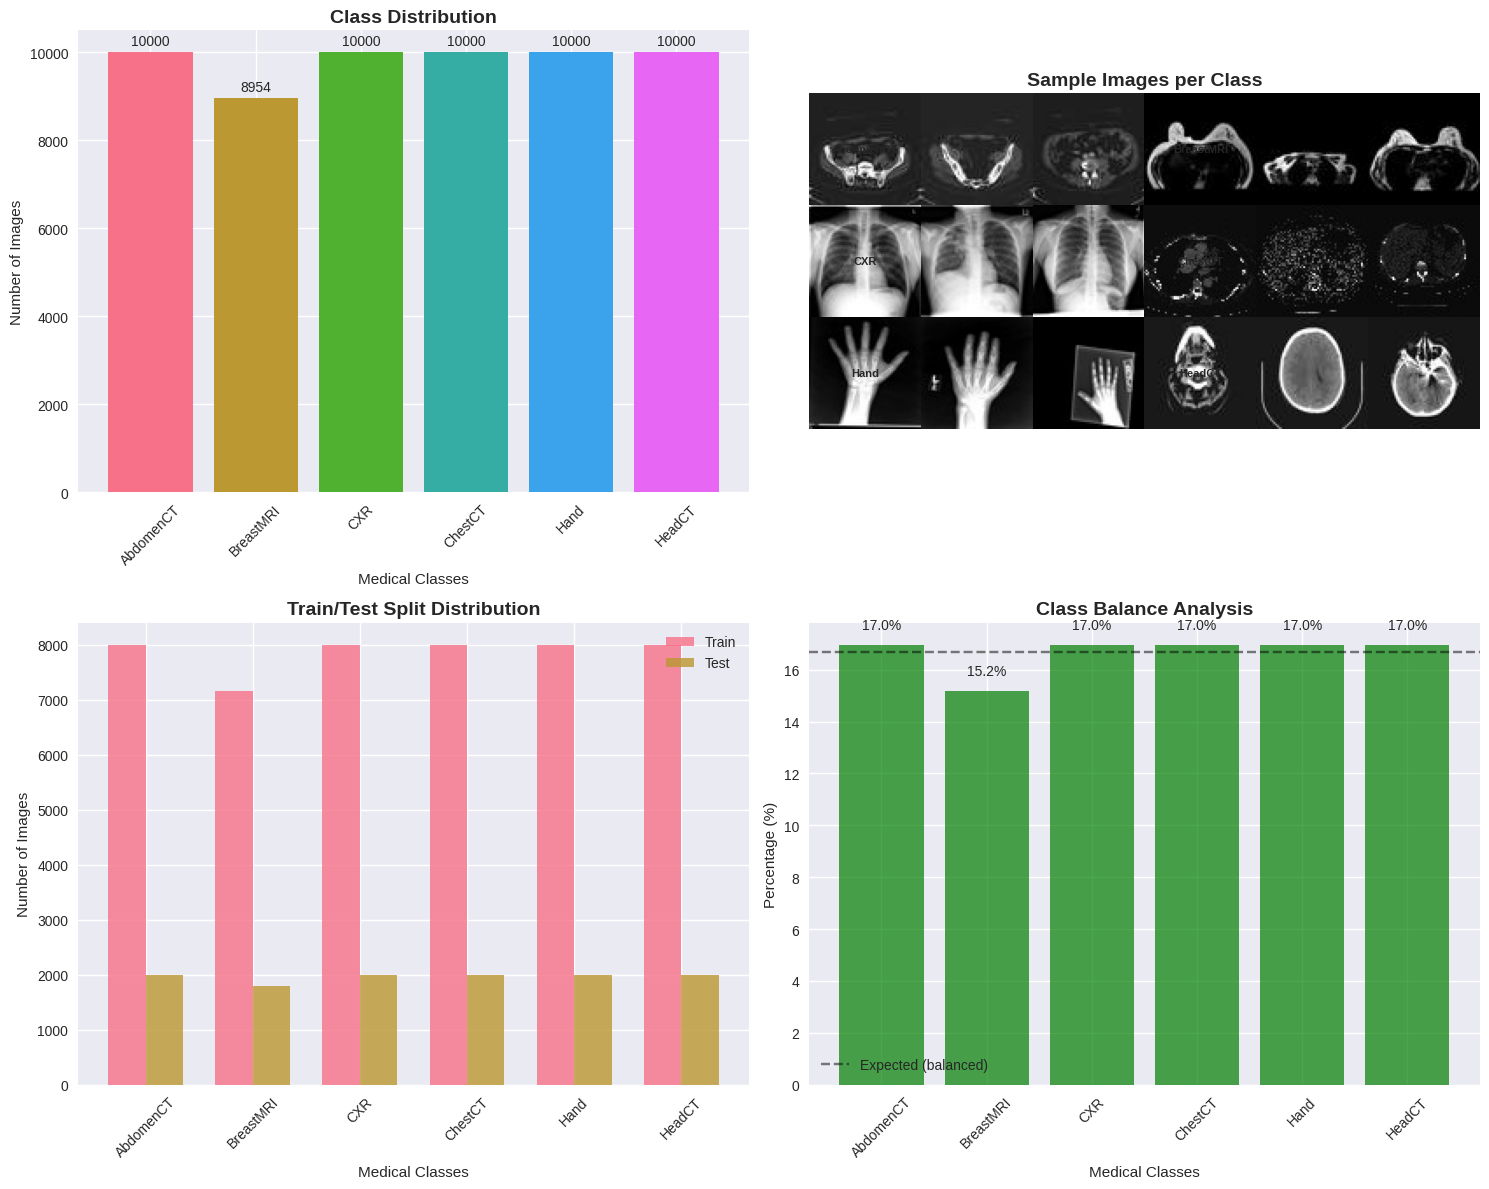

In [62]:
def visualize_data_distribution():
    """Visualize data distribution and quality"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Class distribution
    ax1 = axes[0, 0]
    class_counts = [Counter(labels)[i] for i in range(len(class_names))]
    bars = ax1.bar(class_names, class_counts, color=sns.color_palette("husl", len(class_names)))
    ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Medical Classes')
    ax1.set_ylabel('Number of Images')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(class_counts)*0.01,
                f'{count}', ha='center', va='bottom')
    
    # 2. Sample images from each class
    ax2 = axes[0, 1]
    samples_per_class = 3
    for i, class_name in enumerate(class_names):
        class_indices = [j for j, label in enumerate(labels) if label == i]
        sample_indices = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)
        
        for j, idx in enumerate(sample_indices):
            img = Image.open(image_paths[idx])
            img = img.resize((64, 64))
            
            # Calculate subplot position
            row = i * samples_per_class + j
            col = row % len(class_names)
            row_pos = row // len(class_names)
            
            if row_pos < 3:  # Only show first 3 rows
                ax2.imshow(img, cmap='gray', extent=[col, col+1, 3-row_pos-1, 3-row_pos])
                
                # Add class label for first row
                if j == 0:
                    ax2.text(col + 0.5, 3-row_pos-0.5, class_name, 
                            ha='center', va='center', fontsize=8, fontweight='bold')
    
    ax2.set_xlim(0, len(class_names))
    ax2.set_ylim(0, 3)
    ax2.set_title('Sample Images per Class', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    # 3. Train/Test split distribution
    ax3 = axes[1, 0]
    train_counts = [Counter(train_labels)[i] for i in range(len(class_names))]
    test_counts = [Counter(test_labels)[i] for i in range(len(class_names))]
    
    x = np.arange(len(class_names))
    width = 0.35
    
    ax3.bar(x - width/2, train_counts, width, label='Train', alpha=0.8)
    ax3.bar(x + width/2, test_counts, width, label='Test', alpha=0.8)
    ax3.set_title('Train/Test Split Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Medical Classes')
    ax3.set_ylabel('Number of Images')
    ax3.set_xticks(x)
    ax3.set_xticklabels(class_names, rotation=45)
    ax3.legend()
    
    # 4. Data imbalance visualization
    ax4 = axes[1, 1]
    percentages = [count/len(labels)*100 for count in class_counts]
    colors = ['red' if p < 15 or p > 20 else 'green' for p in percentages]
    
    bars = ax4.bar(class_names, percentages, color=colors, alpha=0.7)
    ax4.axhline(y=100/len(class_names), color='black', linestyle='--', alpha=0.5, label='Expected (balanced)')
    ax4.set_title('Class Balance Analysis', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Medical Classes')
    ax4.set_ylabel('Percentage (%)')
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend()
    
    # Add percentage labels
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

visualize_data_distribution()

In [63]:
def get_model_predictions(models, data_loader):
    """Get ensemble predictions from multiple models"""
    all_predictions = []
    all_probabilities = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            # Move to device
            images = images.to(config.device)
            labels_batch = labels.to(config.device)
            
            # Get predictions from all models
            model_outputs = []
            for model in models:
                model = model.to(config.device)  # Ensure model is on correct device
                outputs = model(images)
                probs = F.softmax(outputs, dim=1)
                model_outputs.append(probs)
            
            # Ensemble predictions (average probabilities)
            avg_probs = torch.mean(torch.stack(model_outputs), dim=0)
            preds = torch.argmax(avg_probs, dim=1)
            
            all_predictions.extend(preds.cpu().numpy())
            all_probabilities.extend(avg_probs.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_probabilities), np.array(all_labels)
# Get predictions
predictions, probabilities, true_labels = get_model_predictions(trained_models, test_loader)

print(f"Generated predictions for {len(predictions)} test samples")
print(f"Overall accuracy: {np.mean(predictions == true_labels)*100:.2f}%")

Generated predictions for 11791 test samples
Overall accuracy: 99.98%


In [64]:
def analyze_model_performance():
    """Comprehensive model performance analysis"""
    print("=" * 60)
    print("MODEL PERFORMANCE ANALYSIS")
    print("=" * 60)
    
    # Overall metrics
    accuracy = np.mean(predictions == true_labels)
    print(f"\n📈 Overall Performance:")
    print(f"  Accuracy: {accuracy*100:.2f}%")
    print(f"  Correct predictions: {np.sum(predictions == true_labels)}/{len(predictions)}")
    print(f"  Wrong predictions: {np.sum(predictions != true_labels)}/{len(predictions)}")
    
    # Per-class performance
    print(f"\n🏥 Per-Class Performance:")
    report = classification_report(true_labels, predictions, target_names=class_names, 
                                   labels=list(range(len(class_names))), output_dict=True)
    
    for i, class_name in enumerate(class_names):
        class_report = report[class_name]
        print(f"  {class_name:12}: Precision={class_report['precision']:.3f}, "
              f"Recall={class_report['recall']:.3f}, F1={class_report['f1-score']:.3f}")
    
    # Identify worst performing classes
    f1_scores = [report[class_name]['f1-score'] for class_name in class_names]
    worst_class_idx = np.argmin(f1_scores)
    best_class_idx = np.argmax(f1_scores)
    
    print(f"\n🏆 Best performing class: {class_names[best_class_idx]} (F1={f1_scores[best_class_idx]:.3f})")
    print(f"⚠️  Worst performing class: {class_names[worst_class_idx]} (F1={f1_scores[worst_class_idx]:.3f})")
    
    return report, f1_scores

performance_report, f1_scores = analyze_model_performance()

MODEL PERFORMANCE ANALYSIS

📈 Overall Performance:
  Accuracy: 99.98%
  Correct predictions: 11789/11791
  Wrong predictions: 2/11791

🏥 Per-Class Performance:
  AbdomenCT   : Precision=1.000, Recall=1.000, F1=1.000
  BreastMRI   : Precision=1.000, Recall=1.000, F1=1.000
  CXR         : Precision=0.999, Recall=1.000, F1=1.000
  ChestCT     : Precision=1.000, Recall=1.000, F1=1.000
  Hand        : Precision=1.000, Recall=0.999, F1=0.999
  HeadCT      : Precision=1.000, Recall=1.000, F1=1.000

🏆 Best performing class: AbdomenCT (F1=1.000)
⚠️  Worst performing class: Hand (F1=0.999)


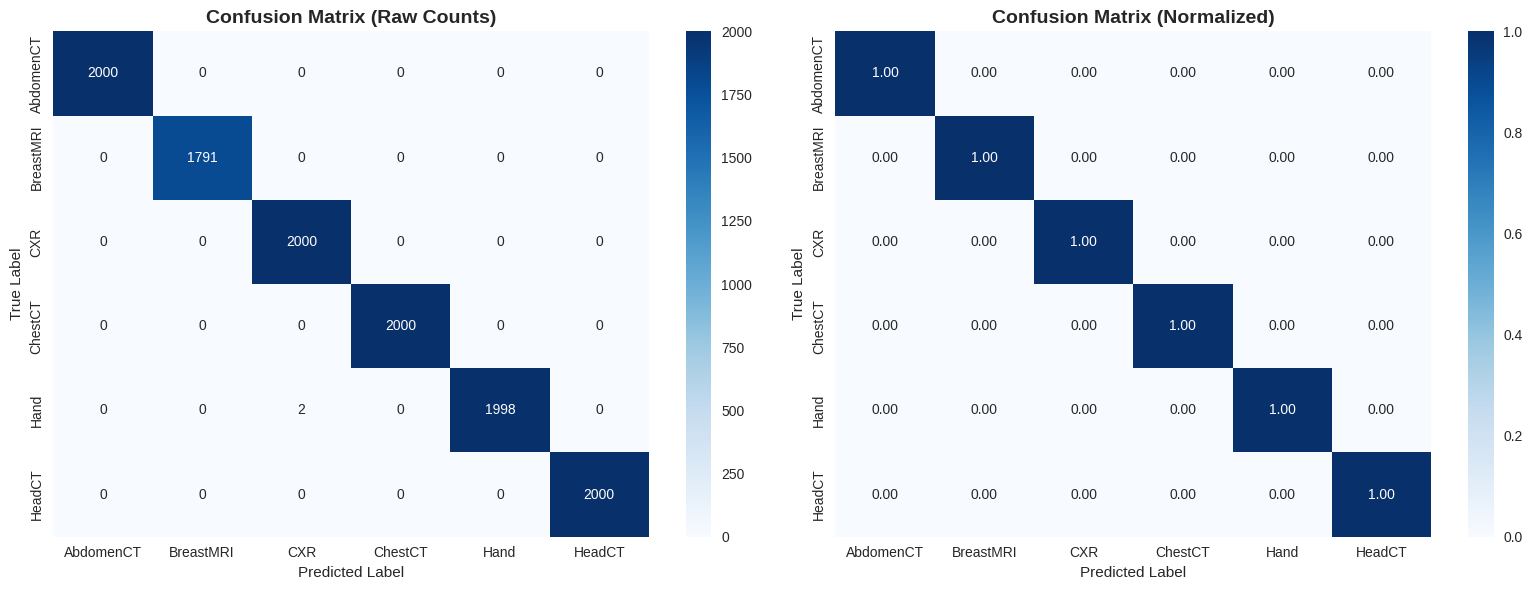


🔍 Confusion Matrix Analysis:

  AbdomenCT:
    Correctly classified: 2000/2000 (100.0%)

  BreastMRI:
    Correctly classified: 1791/1791 (100.0%)

  CXR:
    Correctly classified: 2000/2000 (100.0%)

  ChestCT:
    Correctly classified: 2000/2000 (100.0%)

  Hand:
    Correctly classified: 1998/2000 (99.9%)
    Most confused with: CXR (2 cases)

  HeadCT:
    Correctly classified: 2000/2000 (100.0%)


In [65]:
def plot_confusion_matrix_detailed():
    """Detailed confusion matrix visualization"""
    cm = confusion_matrix(true_labels, predictions)
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')
    
    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()
    
    # Print confusion analysis
    print("\n🔍 Confusion Matrix Analysis:")
    for i, true_class in enumerate(class_names):
        correct = cm[i, i]
        total = cm[i, :].sum()
        
        # Find most confused classes
        confused_with = [(j, cm[i, j]) for j in range(len(class_names)) if j != i and cm[i, j] > 0]
        confused_with.sort(key=lambda x: x[1], reverse=True)
        
        print(f"\n  {true_class}:")
        print(f"    Correctly classified: {correct}/{total} ({correct/total*100:.1f}%)")
        if confused_with:
            print(f"    Most confused with: {class_names[confused_with[0][0]]} ({confused_with[0][1]} cases)")

plot_confusion_matrix_detailed()

## 5. Wrong Prediction Analysis

In [66]:
def analyze_wrong_predictions():
    """Deep analysis of wrong predictions"""
    print("=" * 60)
    print("WRONG PREDICTION ANALYSIS")
    print("=" * 60)
    
    # Find wrong predictions
    wrong_indices = np.where(predictions != true_labels)[0]
    print(f"\n❌ Total wrong predictions: {len(wrong_indices)} ({len(wrong_indices)/len(predictions)*100:.1f}%)")
    
    # Analyze confusion patterns
    confusion_patterns = {}
    for idx in wrong_indices:
        true_label = true_labels[idx]
        pred_label = predictions[idx]
        pattern = f"{class_names[true_label]} → {class_names[pred_label]}"
        confusion_patterns[pattern] = confusion_patterns.get(pattern, 0) + 1
    
    print(f"\n🔄 Top Confusion Patterns:")
    sorted_patterns = sorted(confusion_patterns.items(), key=lambda x: x[1], reverse=True)
    for pattern, count in sorted_patterns[:10]:
        print(f"  {pattern}: {count} cases")
    
    # Analyze confidence scores for wrong predictions
    wrong_confidences = []
    correct_confidences = []
    
    for i in range(len(predictions)):
        confidence = np.max(probabilities[i])
        if predictions[i] != true_labels[i]:
            wrong_confidences.append(confidence)
        else:
            correct_confidences.append(confidence)
    
    print(f"\n📊 Confidence Analysis:")
    print(f"  Wrong predictions - Mean confidence: {np.mean(wrong_confidences):.3f}")
    print(f"  Correct predictions - Mean confidence: {np.mean(correct_confidences):.3f}")
    print(f"  High confidence wrong predictions (>0.9): {np.sum(np.array(wrong_confidences) > 0.9)}")
    
    return wrong_indices, confusion_patterns

wrong_indices, confusion_patterns = analyze_wrong_predictions()

WRONG PREDICTION ANALYSIS

❌ Total wrong predictions: 2 (0.0%)

🔄 Top Confusion Patterns:
  Hand → CXR: 2 cases

📊 Confidence Analysis:
  Wrong predictions - Mean confidence: 0.621
  Correct predictions - Mean confidence: 1.000
  High confidence wrong predictions (>0.9): 0



🖼️  Visualizing the 2 wrong prediction images:


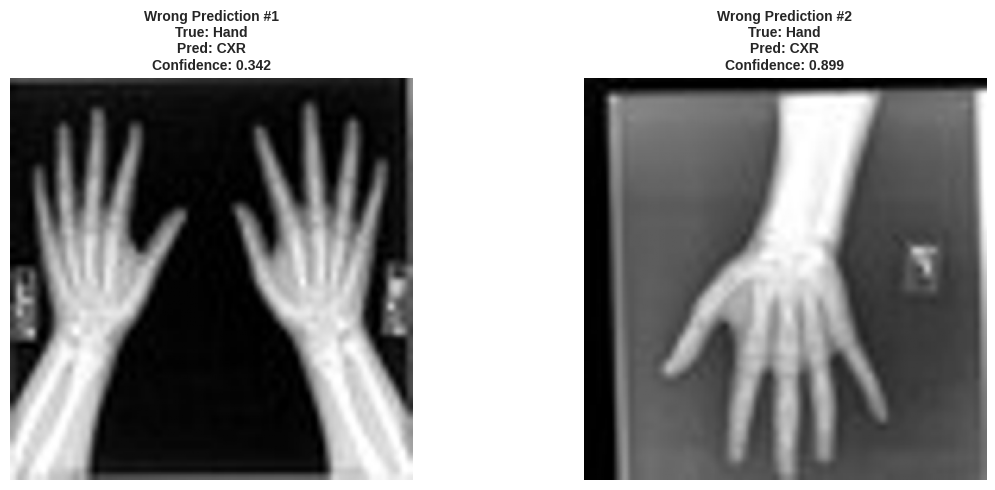

In [67]:
# Visualize the two wrong prediction images
print(f"\n🖼️  Visualizing the {len(wrong_indices)} wrong prediction images:")
fig, axes = plt.subplots(1, len(wrong_indices), figsize=(12, 5))
if len(wrong_indices) == 1:
    axes = [axes]  # Make it iterable for single image

for i, idx in enumerate(wrong_indices):
    img = Image.open(test_paths[idx])
    img = img.resize((256, 256))
    
    true_label = class_names[true_labels[idx]]
    pred_label = class_names[predictions[idx]]
    confidence = np.max(probabilities[idx])
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Wrong Prediction #{i+1}\nTrue: {true_label}\nPred: {pred_label}\nConfidence: {confidence:.3f}', 
                     fontweight='bold', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 6. Grad-CAM Visualization

In [68]:
class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.gradients = None
        self.activations = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        
        for name, module in self.model.named_modules():
            if name == self.target_layer_name:
                module.register_forward_hook(forward_hook)
                module.register_full_backward_hook(backward_hook)  # ✅ fixed
                break

    def generate_cam(self, input_tensor, class_idx):
        self.model.eval()
        input_tensor.requires_grad_(True)  # ✅ fixed
        
        output = self.model(input_tensor)
        self.model.zero_grad()
        
        class_score = output[0, class_idx]
        class_score.backward()
        
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        weights = torch.mean(gradients, dim=(1, 2))
        cam = torch.sum(weights[:, None, None] * activations, dim=0)
        
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # ✅ avoid div/0
        
        return cam.detach().cpu().numpy()


def create_gradcam_visualization(model, image_path, true_label, predicted_label, confidence):
    img = Image.open(image_path).convert('L')
    original_img = img.resize((256, 256))  # only for display

    # ✅ Keep original training resolution
    transform = transforms.Compose([
        transforms.Resize((64, 64)),       # match training size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    input_tensor = transform(img).unsqueeze(0).to(config.device)
    input_tensor.requires_grad_(True)

    # ✅ Auto-detect last conv layer
    last_conv_layer = None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv_layer = name
    print(f"✅ Using layer: {last_conv_layer}")

    grad_cam = GradCAM(model, last_conv_layer)
    class_idx = config.class_names.index(predicted_label)
    cam = grad_cam.generate_cam(input_tensor, class_idx)

    # ✅ Resize CAM to display size (256x256) for better visualization
    cam_resized = cv2.resize(cam, (256, 256))

    original_rgb = np.stack([np.array(original_img)]*3, axis=-1).astype(np.float32) / 255.0

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    ax1.imshow(original_img, cmap='gray')
    ax1.set_title(f'Original Image\nTrue: {true_label}\nPred: {predicted_label}\nConf: {confidence:.3f}')
    ax1.axis('off')

    heatmap = ax2.imshow(cam_resized, cmap='jet')
    ax2.set_title('Grad-CAM Heatmap')
    ax2.axis('off')
    plt.colorbar(heatmap, ax=ax2, fraction=0.046, pad=0.04)

    ax3.imshow(original_rgb)
    ax3.imshow(cam_resized, cmap='jet', alpha=0.4)
    ax3.set_title('Grad-CAM Overlay')
    ax3.axis('off')

    plt.tight_layout()
    return fig

GRAD-CAM ANALYSIS

📊 Case Distribution for Grad-CAM Analysis:
  correct_high_conf: 11781 cases
  correct_mid_conf: 5 cases
  correct_low_conf: 3 cases
  wrong_high_conf: 0 cases
  wrong_middle_conf: 1 cases
  wrong_low_conf: 1 cases

🧠 Using model: SimpleCNN

🔍 CORRECT_HIGH_CONF — showing 3 examples

  📁 Image    : 004409.jpeg
  ✅ True     : AbdomenCT
  🔮 Predicted: AbdomenCT
  📈 Confidence: 1.000
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_high_conf_004409.png


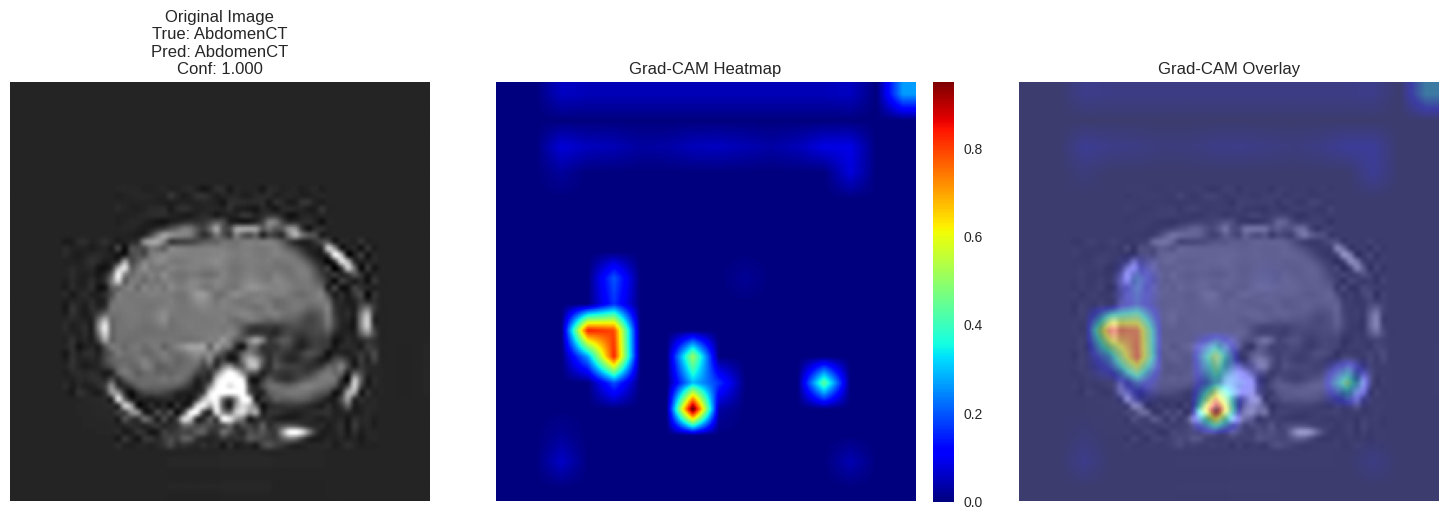


  📁 Image    : 000004.jpeg
  ✅ True     : AbdomenCT
  🔮 Predicted: AbdomenCT
  📈 Confidence: 1.000
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_high_conf_000004.png


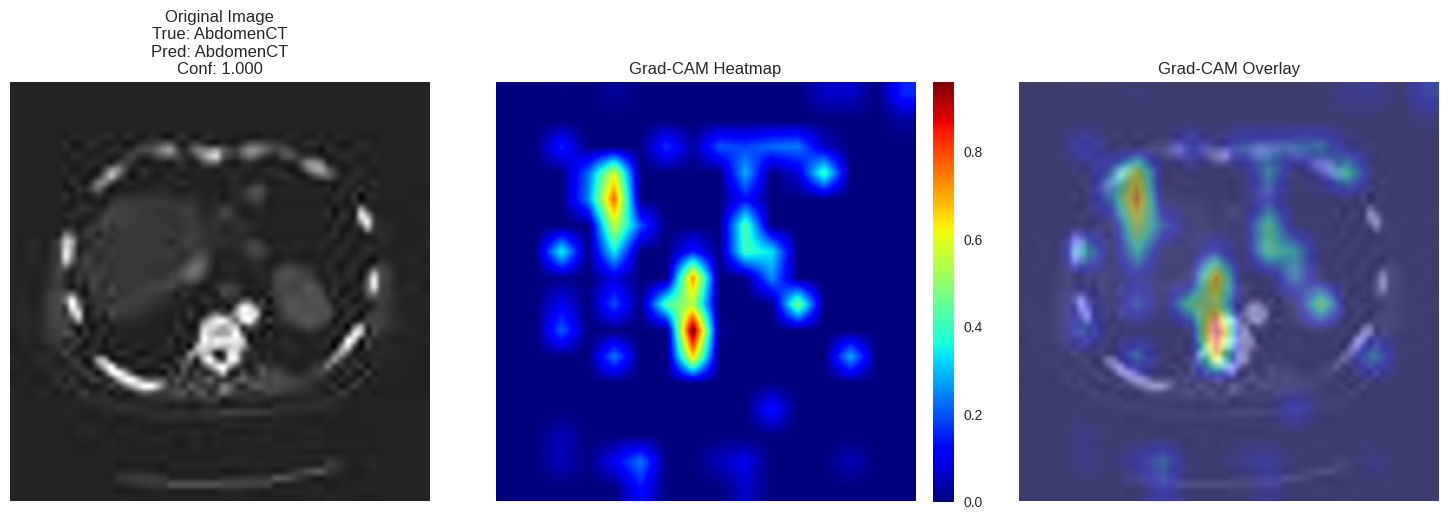


  📁 Image    : 002216.jpeg
  ✅ True     : HeadCT
  🔮 Predicted: HeadCT
  📈 Confidence: 1.000
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_high_conf_002216.png


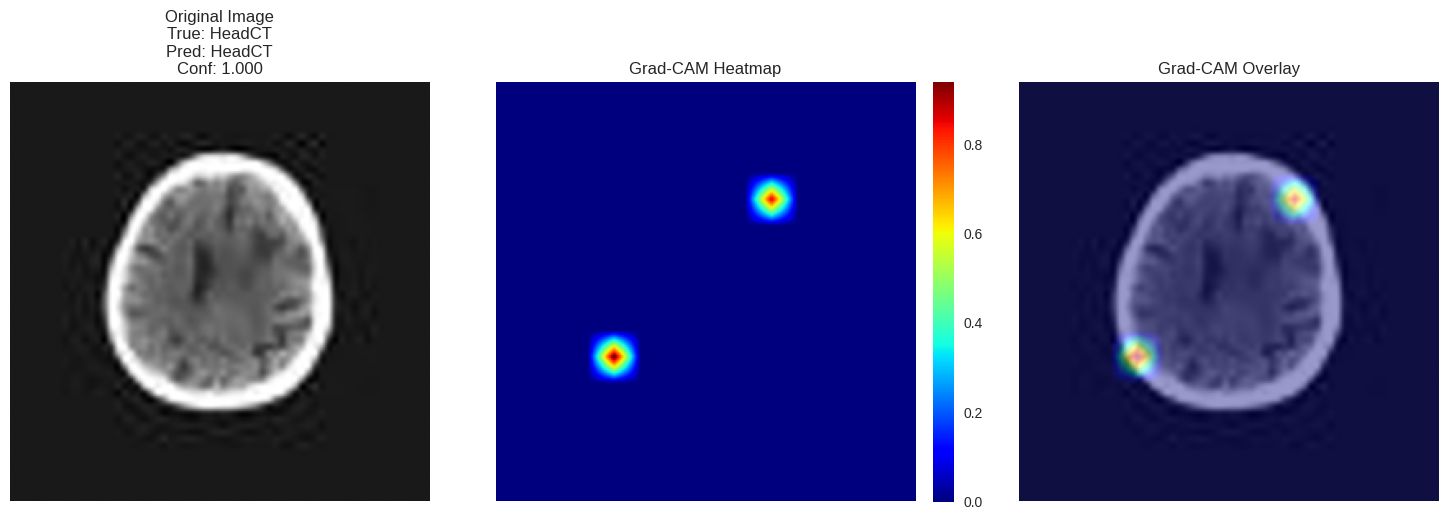


🔍 CORRECT_MID_CONF — showing 3 examples

  📁 Image    : 000753.jpeg
  ✅ True     : AbdomenCT
  🔮 Predicted: AbdomenCT
  📈 Confidence: 0.798
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_mid_conf_000753.png


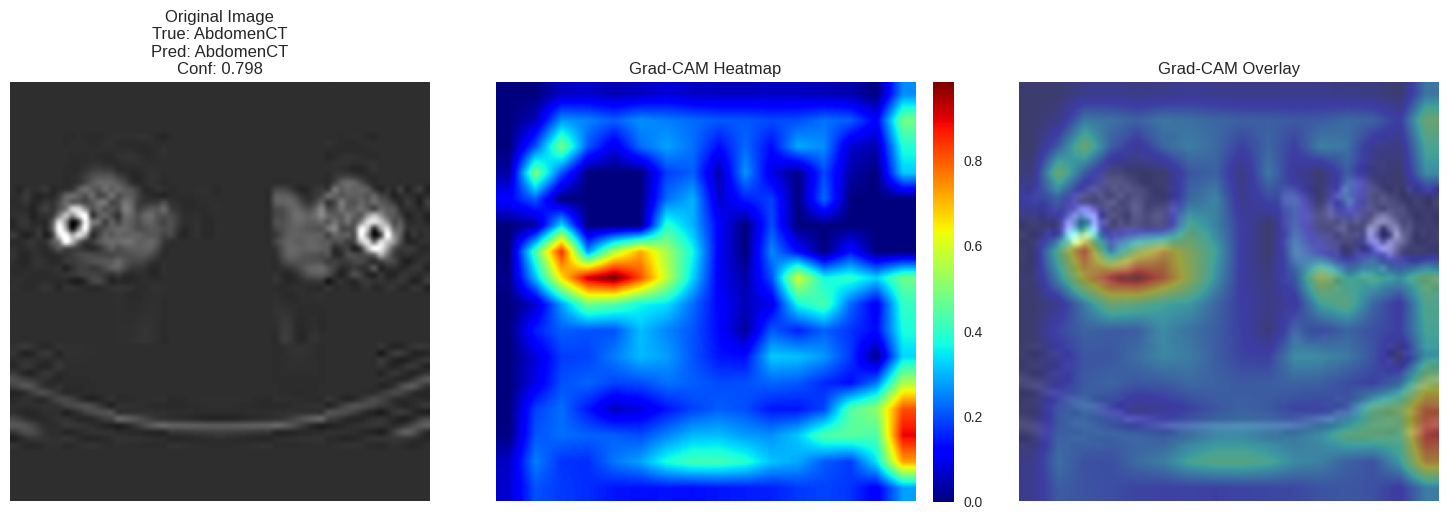


  📁 Image    : 003645.jpeg
  ✅ True     : Hand
  🔮 Predicted: Hand
  📈 Confidence: 0.733
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_mid_conf_003645.png


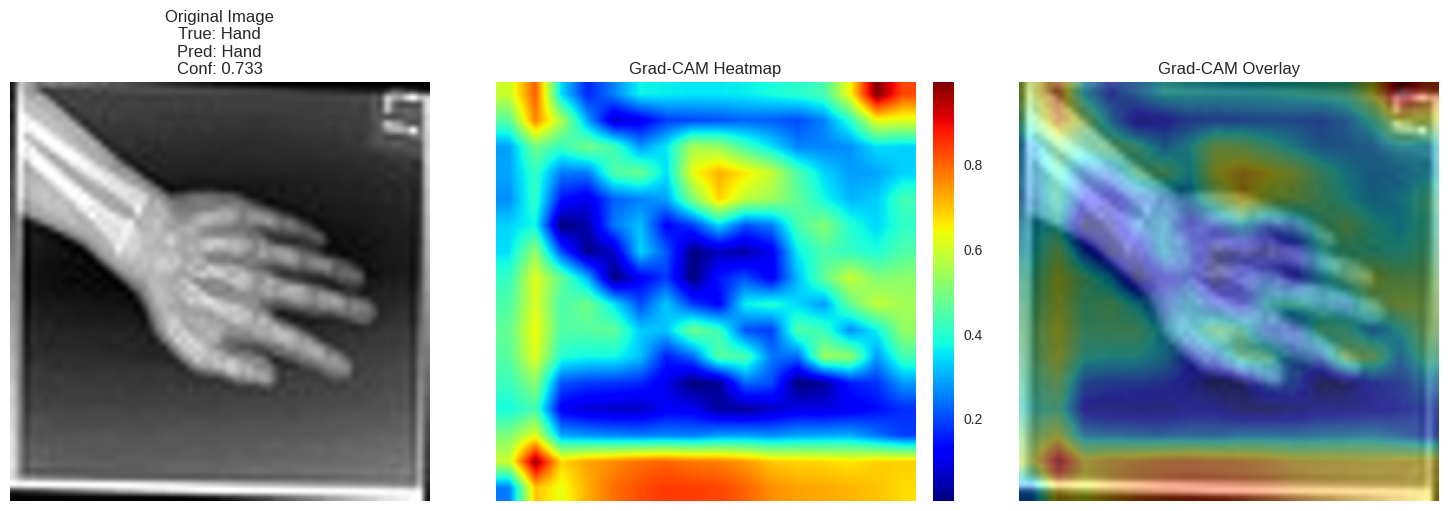


  📁 Image    : 008722.jpeg
  ✅ True     : Hand
  🔮 Predicted: Hand
  📈 Confidence: 0.760
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_mid_conf_008722.png


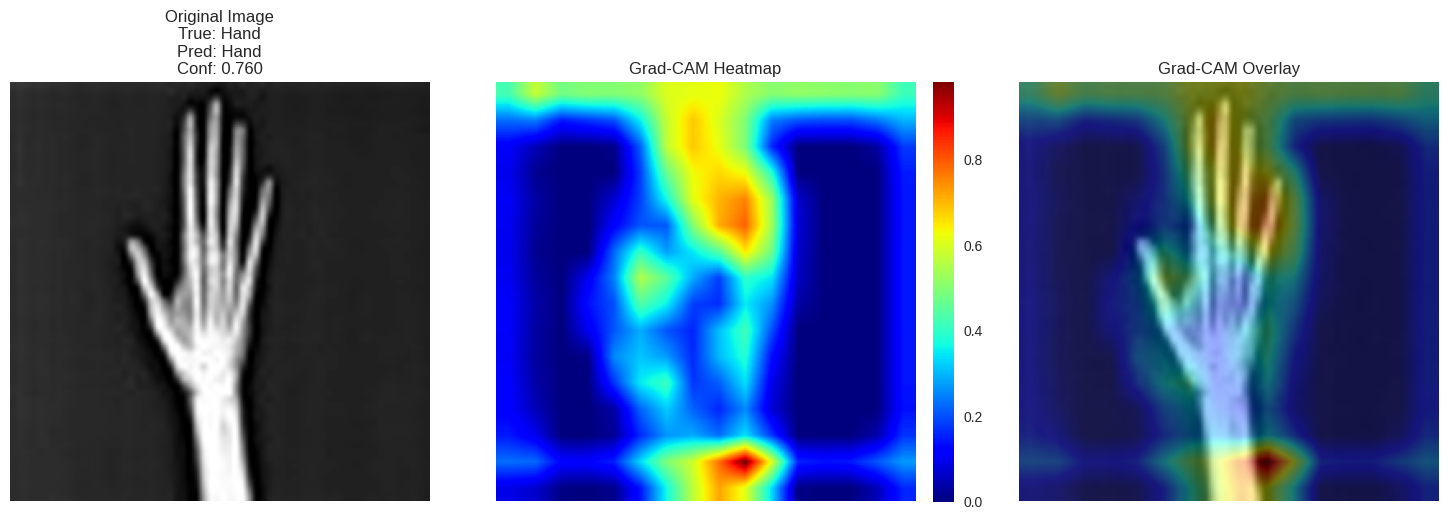


🔍 CORRECT_LOW_CONF — showing 3 examples

  📁 Image    : 001721.jpeg
  ✅ True     : CXR
  🔮 Predicted: CXR
  📈 Confidence: 0.665
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_low_conf_001721.png


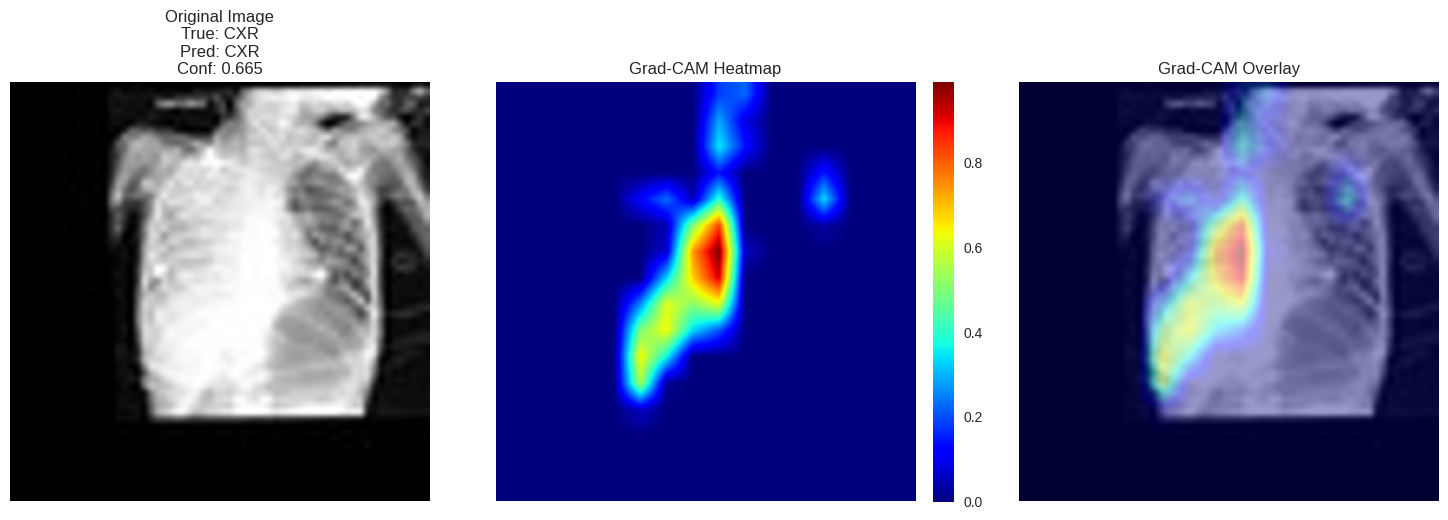


  📁 Image    : 007256.jpeg
  ✅ True     : CXR
  🔮 Predicted: CXR
  📈 Confidence: 0.692
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_low_conf_007256.png


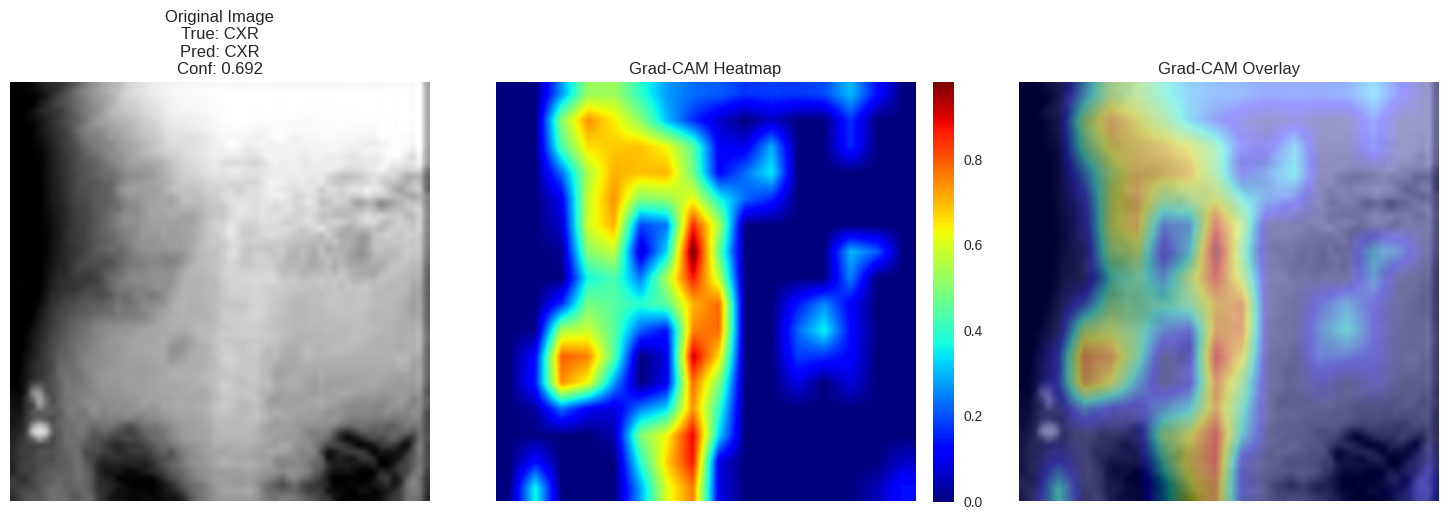


  📁 Image    : 006143.jpeg
  ✅ True     : CXR
  🔮 Predicted: CXR
  📈 Confidence: 0.637
✅ Using layer: features.16
  💾 Saved to : gradcam_results/correct_low_conf_006143.png


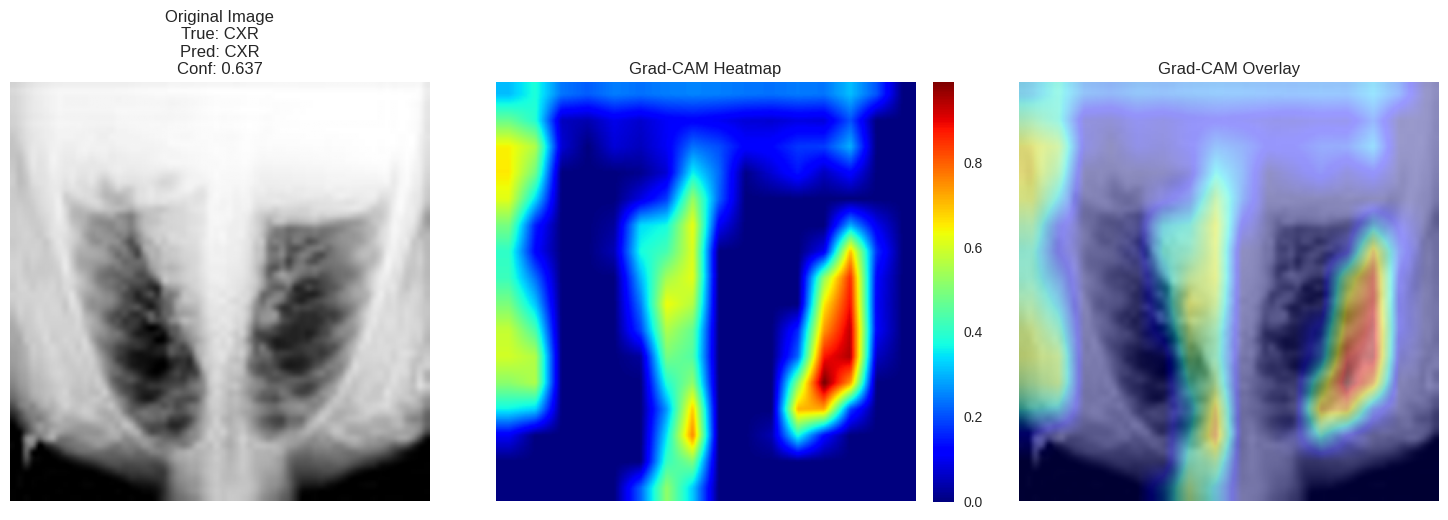


⚠️  No wrong_high_conf cases found

🔍 WRONG_MIDDLE_CONF — showing 1 examples

  📁 Image    : 000311.jpeg
  ✅ True     : Hand
  🔮 Predicted: CXR
  📈 Confidence: 0.899
✅ Using layer: features.16
  💾 Saved to : gradcam_results/wrong_middle_conf_000311.png


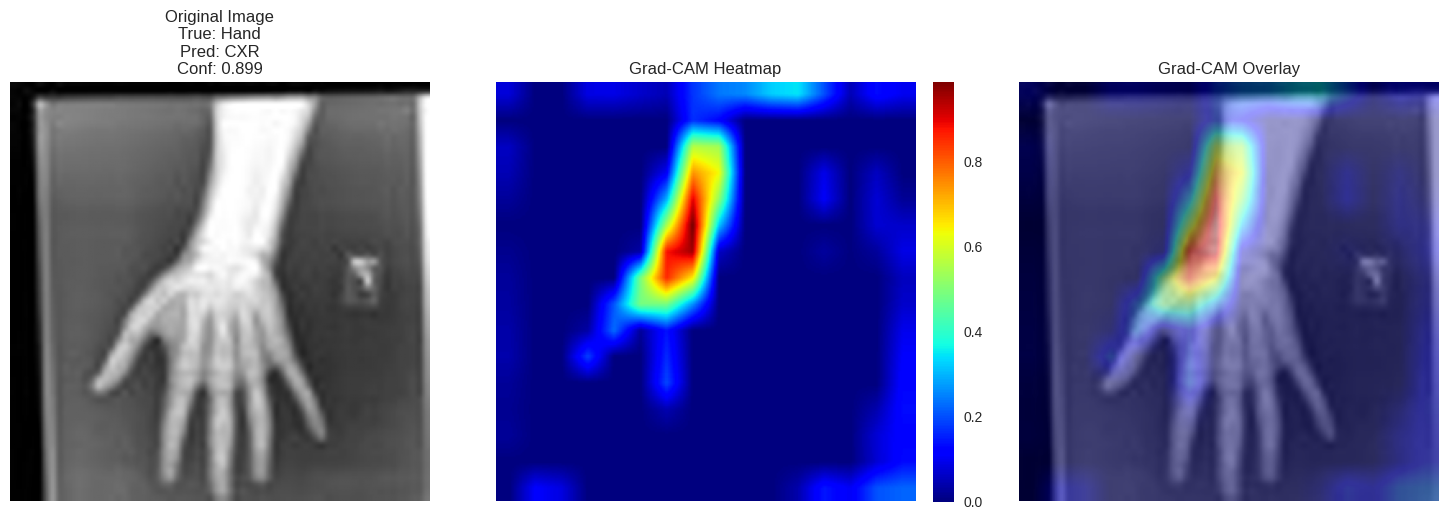


🔍 WRONG_LOW_CONF — showing 1 examples

  📁 Image    : 006398.jpeg
  ✅ True     : Hand
  🔮 Predicted: CXR
  📈 Confidence: 0.342
✅ Using layer: features.16
  💾 Saved to : gradcam_results/wrong_low_conf_006398.png


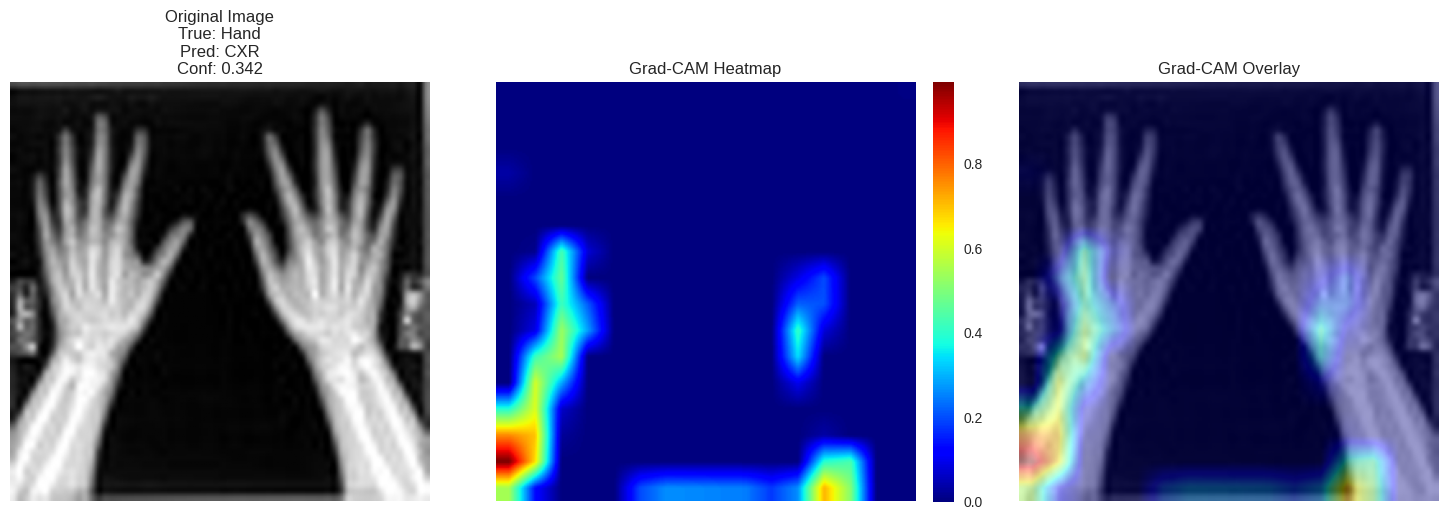


✅ All visualizations saved to: gradcam_results/


In [69]:
def analyze_gradcam_samples(save_dir="gradcam_results", seed=42):
    """Generate Grad-CAM visualizations for interesting cases"""
    print("=" * 60)
    print("GRAD-CAM ANALYSIS")
    print("=" * 60)

    np.random.seed(seed)  # ✅ reproducible sampling
    os.makedirs(save_dir, exist_ok=True)  # ✅ save outputs

    # ✅ Fixed: complete confidence coverage
    cases_to_analyze = {
        'correct_high_conf':   [],   # correct   > 0.9
        'correct_mid_conf':    [],   # correct   0.7–0.9  ← NEW
        'correct_low_conf':    [],   # correct   < 0.7
        'wrong_high_conf':     [],   # wrong     > 0.9
        'wrong_middle_conf':   [],   # wrong     0.7–0.9
        'wrong_low_conf':      [],   # wrong     < 0.7
    }

    for i in range(len(predictions)):
        confidence = np.max(probabilities[i])
        is_correct = predictions[i] == true_labels[i]

        if is_correct:
            if confidence > 0.9:
                cases_to_analyze['correct_high_conf'].append(i)
            elif confidence >= 0.7:
                cases_to_analyze['correct_mid_conf'].append(i)   # ✅ fixed gap
            else:
                cases_to_analyze['correct_low_conf'].append(i)
        else:
            if confidence > 0.9:
                cases_to_analyze['wrong_high_conf'].append(i)
            elif confidence >= 0.7:
                cases_to_analyze['wrong_middle_conf'].append(i)
            else:
                cases_to_analyze['wrong_low_conf'].append(i)

    print(f"\n📊 Case Distribution for Grad-CAM Analysis:")
    for case_type, indices in cases_to_analyze.items():
        print(f"  {case_type}: {len(indices)} cases")

    # ✅ Use best model, or let user choose
    model = trained_models[0]
    print(f"\n🧠 Using model: {type(model).__name__}")

    for case_type, indices in cases_to_analyze.items():
        if len(indices) == 0:
            print(f"\n⚠️  No {case_type} cases found")
            continue

        n_samples = min(3, len(indices))
        print(f"\n{'='*50}")
        print(f"🔍 {case_type.upper()} — showing {n_samples} examples")
        print(f"{'='*50}")

        sample_indices = np.random.choice(indices, n_samples, replace=False)

        for idx in sample_indices:
            true_label  = class_names[true_labels[idx]]
            pred_label  = class_names[predictions[idx]]
            confidence  = np.max(probabilities[idx])

            print(f"\n  📁 Image    : {Path(test_paths[idx]).name}")
            print(f"  ✅ True     : {true_label}")
            print(f"  🔮 Predicted: {pred_label}")
            print(f"  📈 Confidence: {confidence:.3f}")

            fig = create_gradcam_visualization(
                model, test_paths[idx], true_label, pred_label, confidence
            )

            if fig is not None:
                # ✅ Save figure
                save_path = os.path.join(
                    save_dir,
                    f"{case_type}_{Path(test_paths[idx]).stem}.png"
                )
                fig.savefig(save_path, bbox_inches='tight', dpi=150)
                print(f"  💾 Saved to : {save_path}")

                plt.show()
                plt.close(fig)  # ✅ free memory
            else:
                print(f"  ❌ Grad-CAM failed for this image")

    print(f"\n✅ All visualizations saved to: {save_dir}/")

analyze_gradcam_samples()

In [70]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from pathlib import Path
import os

# ============================================================
# GRAD-CAM++ IMPLEMENTATION
# ============================================================

class GradCAMPlusPlus:
    """
    Grad-CAM++ implementation for better multi-region coverage.
    Uses second-order gradients for more precise localization.
    """
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output  # [B, C, H, W]

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]  # [B, C, H, W]

        for name, module in self.model.named_modules():
            if name == self.target_layer_name:
                module.register_forward_hook(forward_hook)
                module.register_full_backward_hook(backward_hook)  # ✅ not deprecated
                print(f"✅ Hooks registered on: {name}")
                break

    def generate_cam(self, input_tensor, class_idx):
        self.model.eval()
        input_tensor = input_tensor.clone().requires_grad_(True)

        # Forward pass
        output = self.model(input_tensor)
        self.model.zero_grad()

        # Backward pass for target class
        class_score = output[0, class_idx]
        class_score.backward()

        # ── Grad-CAM++ weight computation ──────────────────────────────
        gradients   = self.gradients[0]    # [C, H, W]
        activations = self.activations[0]  # [C, H, W]

        # Second-order & third-order gradient approximation
        grad_2 = gradients ** 2
        grad_3 = gradients ** 3

        # Global sum of activations per channel
        global_sum = activations.sum(dim=(1, 2), keepdim=True)  # [C, 1, 1]

        # Alpha: how much each spatial location contributes
        # α_ck = grad²_ck / (2·grad²_ck + global_sum·grad³_ck + ε)
        eps = 1e-8
        alpha_num   = grad_2
        alpha_denom = 2 * grad_2 + global_sum * grad_3 + eps
        alpha       = alpha_num / alpha_denom  # [C, H, W]

        # Only keep positive gradients (ReLU on gradients)
        weights = (alpha * F.relu(gradients)).sum(dim=(1, 2))  # [C]

        # Weighted combination of activation maps
        cam = torch.sum(weights[:, None, None] * activations, dim=0)  # [H, W]

        # ReLU + normalize
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)

        return cam.detach().cpu().numpy()


# ============================================================
# VISUALIZATION FUNCTION
# ============================================================

def create_gradcampp_visualization(model, image_path, true_label,
                                   predicted_label, confidence,
                                   save_dir=None):
    """
    Create Grad-CAM++ visualization for a single image.
    Automatically detects last conv layer and training resolution.
    """

    # ── Auto-detect last conv layer ────────────────────────────────────
    last_conv_layer = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv_layer = name
    if last_conv_layer is None:
        print("❌ No Conv2d layer found in model")
        return None
    print(f"🎯 Target layer: {last_conv_layer}")

    # ── Auto-detect training input size ────────────────────────────────
    # ── Use known input size for Medical MNIST ───────────────────────────
    input_size = 64  # Medical MNIST images are 64x64
    print(f"📐 Using input size: {input_size}x{input_size}")

    # ── Load image ──────────────────────────────────────────────────────
    img        = Image.open(image_path).convert('L')
    display_img = img.resize((256, 256))  # for visualization only

    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    input_tensor = transform(img).unsqueeze(0).to(
        next(model.parameters()).device
    )

    # ── Run Grad-CAM++ ──────────────────────────────────────────────────
    try:
        grad_cam_pp = GradCAMPlusPlus(model, last_conv_layer)
        class_idx   = config.class_names.index(predicted_label)
        cam         = grad_cam_pp.generate_cam(input_tensor, class_idx)
    except Exception as e:
        print(f"❌ Grad-CAM++ failed: {e}")
        return None

    # ── Resize CAM to display size ──────────────────────────────────────
    cam_resized = cv2.resize(cam, (256, 256),
                             interpolation=cv2.INTER_LINEAR)

    # ── Convert grayscale to RGB for overlay ────────────────────────────
    original_rgb = np.stack(
        [np.array(display_img)] * 3, axis=-1
    ).astype(np.float32) / 255.0

    # ── Apply colormap ──────────────────────────────────────────────────
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
    overlay       = 0.6 * original_rgb + 0.4 * heatmap_color
    overlay       = np.clip(overlay, 0, 1)

    # ── Plot ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"Grad-CAM++  |  True: {true_label}  |  "
        f"Pred: {predicted_label}  |  Conf: {confidence:.3f}",
        fontsize=13, fontweight='bold'
    )

    axes[0].imshow(display_img, cmap='gray')
    axes[0].set_title('Original X-Ray')
    axes[0].axis('off')

    im = axes[1].imshow(cam_resized, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Grad-CAM++ Heatmap')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(overlay)
    axes[2].set_title('Grad-CAM++ Overlay')
    axes[2].axis('off')

    plt.tight_layout()

    # ── Save if requested ───────────────────────────────────────────────
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(
            save_dir,
            f"gradcampp_{Path(image_path).stem}.png"
        )
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"💾 Saved: {save_path}")

    return fig


GRAD-CAM++ ANALYSIS

📊 Case Distribution:
  correct_high_conf: 11781 cases
  correct_mid_conf: 5 cases
  correct_low_conf: 3 cases
  wrong_high_conf: 0 cases
  wrong_middle_conf: 1 cases
  wrong_low_conf: 1 cases

🧠 Model: SimpleCNN

🔍 CORRECT_HIGH_CONF — 3 examples

  📁 004409.jpeg
  ✅ True: AbdomenCT | 🔮 Pred: AbdomenCT | 📈 Conf: 1.000
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_004409.png


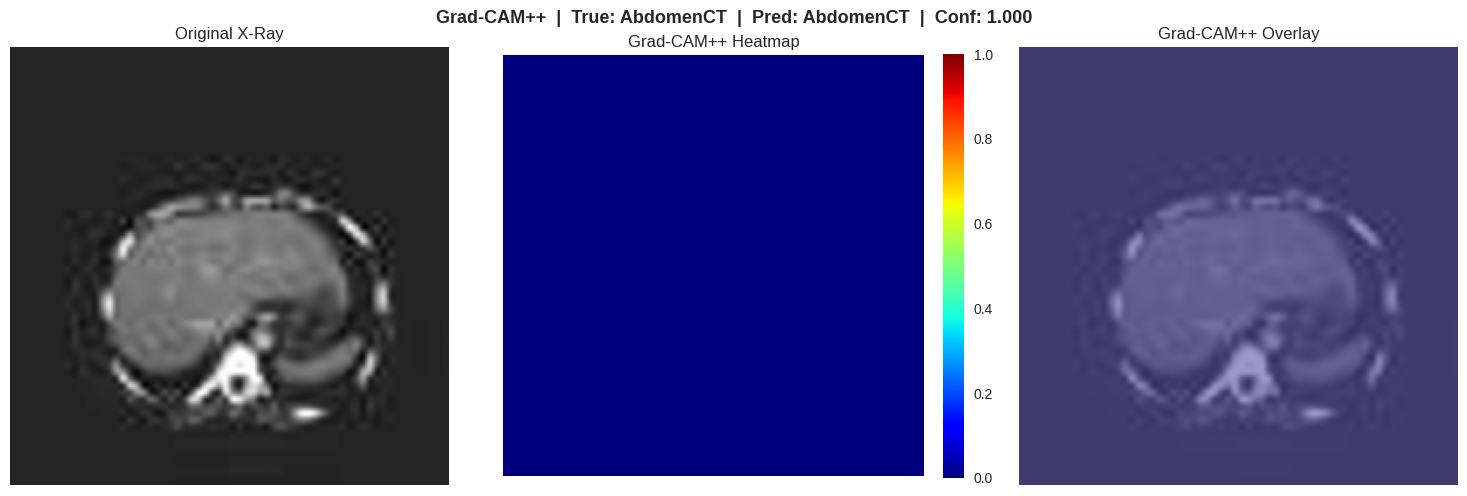


  📁 000004.jpeg
  ✅ True: AbdomenCT | 🔮 Pred: AbdomenCT | 📈 Conf: 1.000
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_000004.png


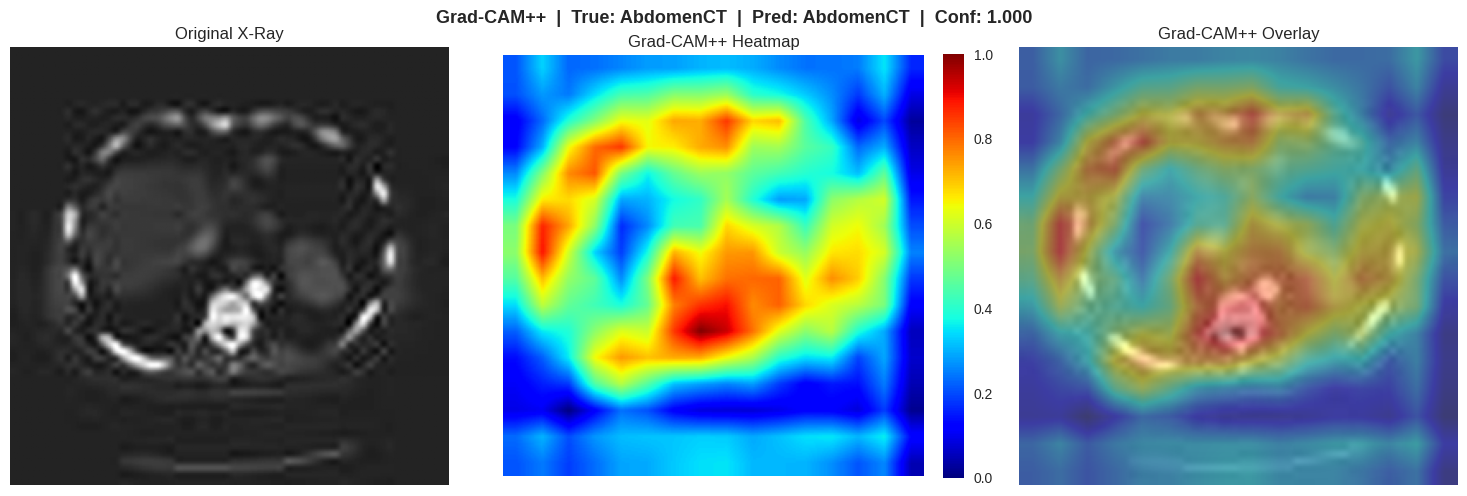


  📁 002216.jpeg
  ✅ True: HeadCT | 🔮 Pred: HeadCT | 📈 Conf: 1.000
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_002216.png


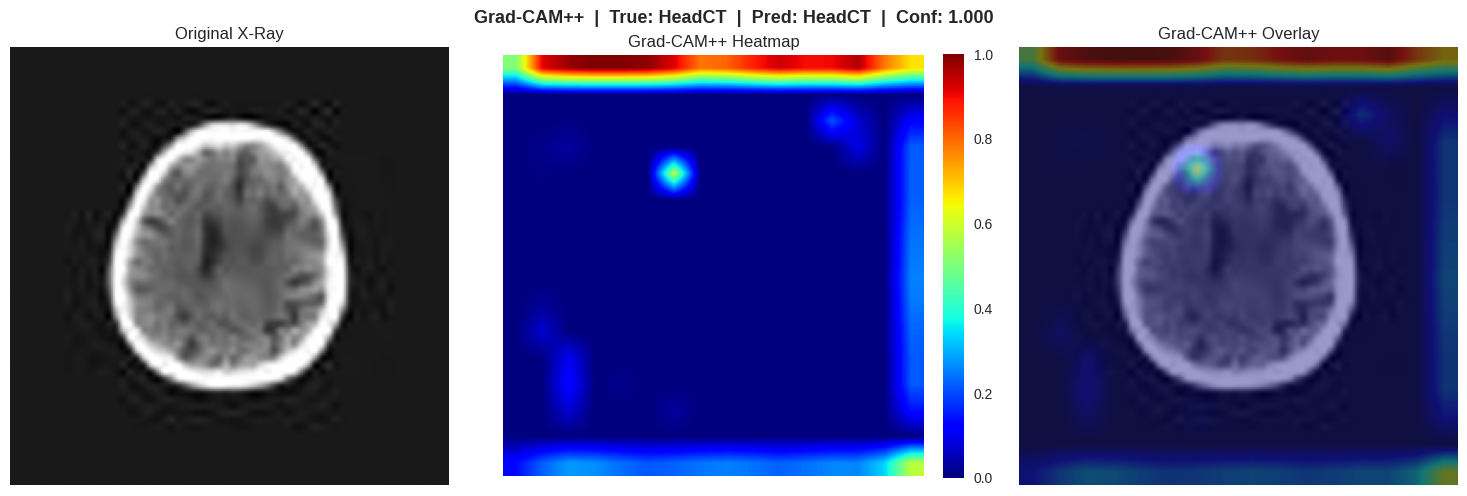


🔍 CORRECT_MID_CONF — 3 examples

  📁 000753.jpeg
  ✅ True: AbdomenCT | 🔮 Pred: AbdomenCT | 📈 Conf: 0.798
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_000753.png


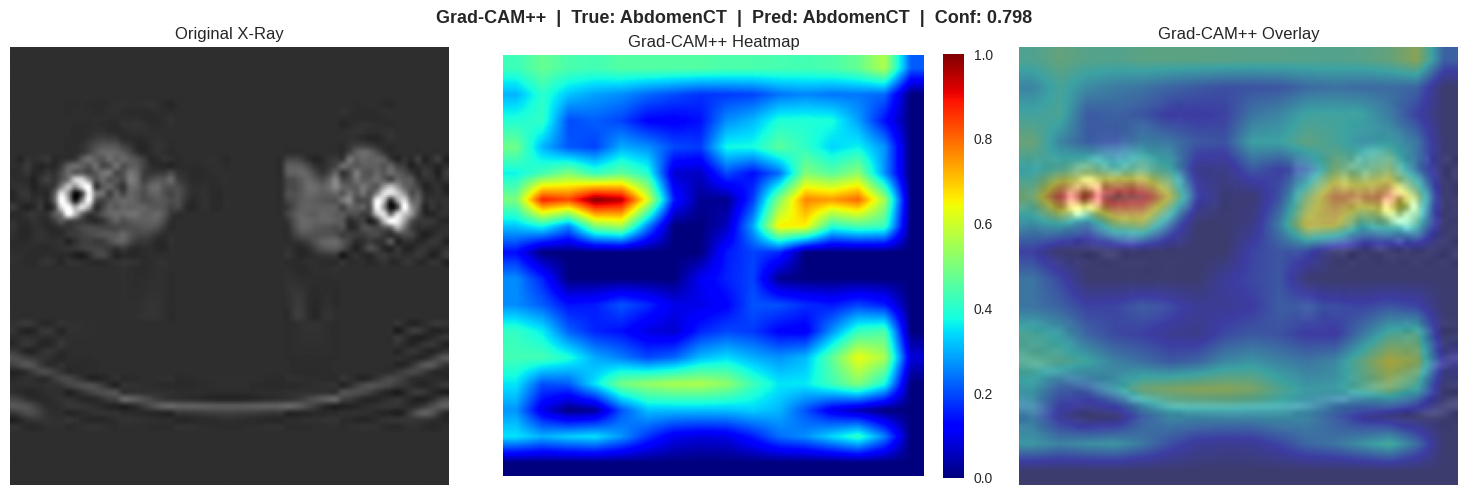


  📁 003645.jpeg
  ✅ True: Hand | 🔮 Pred: Hand | 📈 Conf: 0.733
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_003645.png


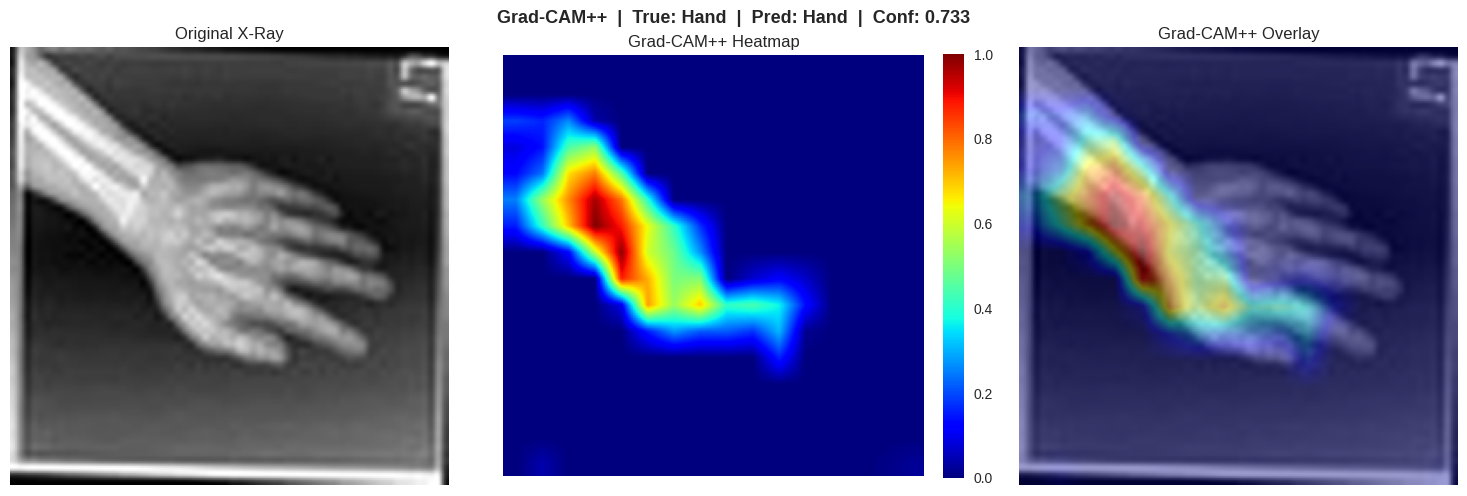


  📁 008722.jpeg
  ✅ True: Hand | 🔮 Pred: Hand | 📈 Conf: 0.760
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_008722.png


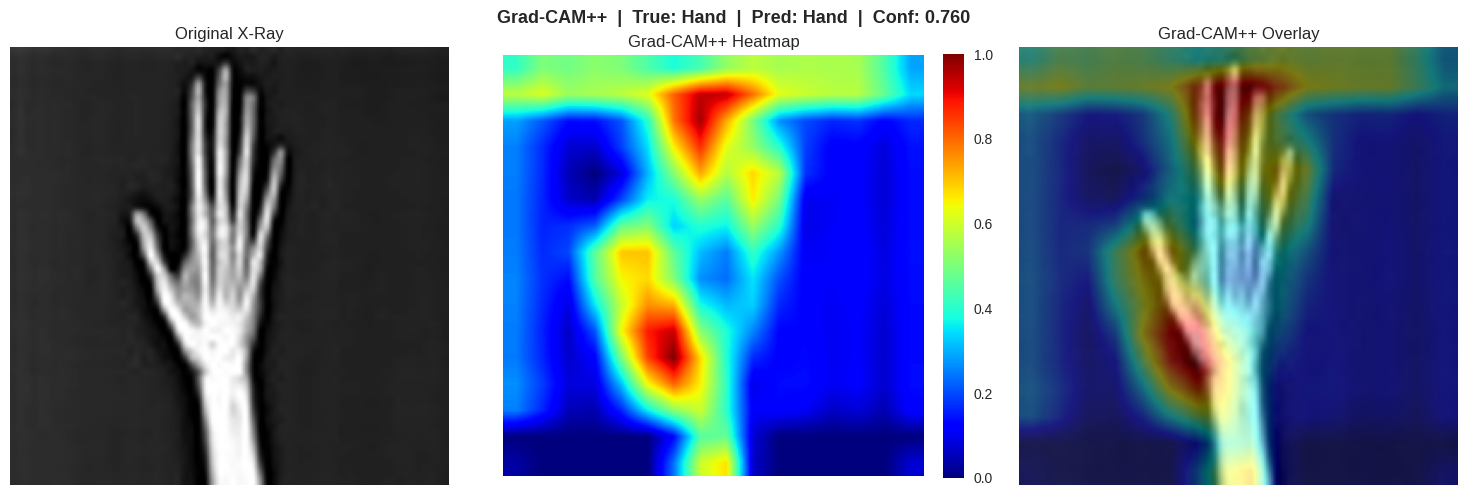


🔍 CORRECT_LOW_CONF — 3 examples

  📁 001721.jpeg
  ✅ True: CXR | 🔮 Pred: CXR | 📈 Conf: 0.665
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_001721.png


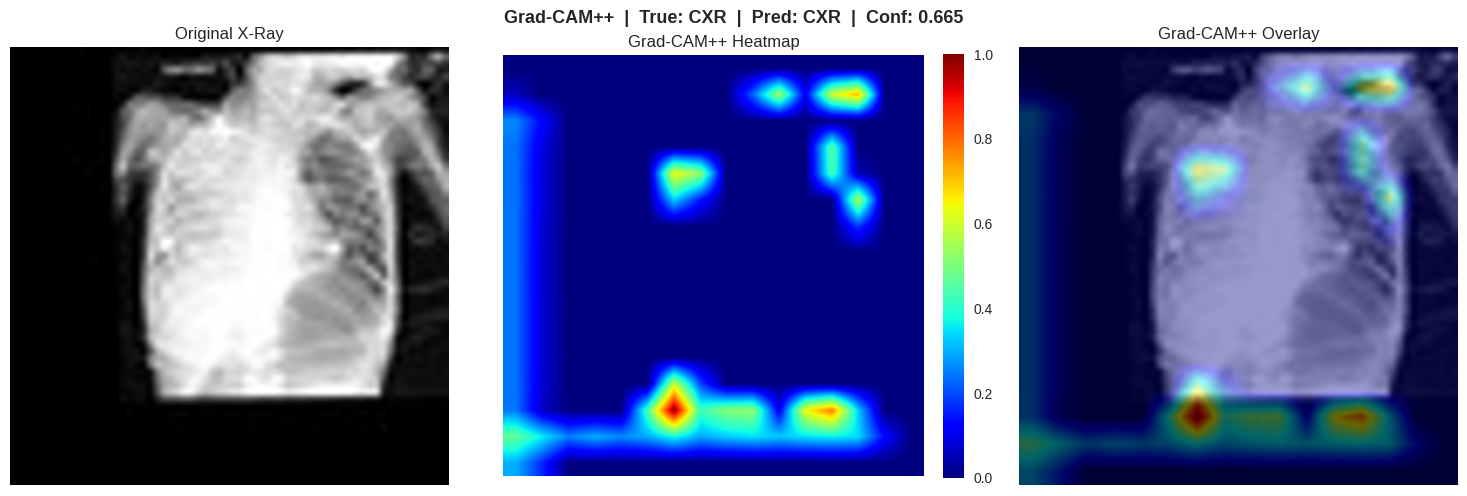


  📁 007256.jpeg
  ✅ True: CXR | 🔮 Pred: CXR | 📈 Conf: 0.692
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_007256.png


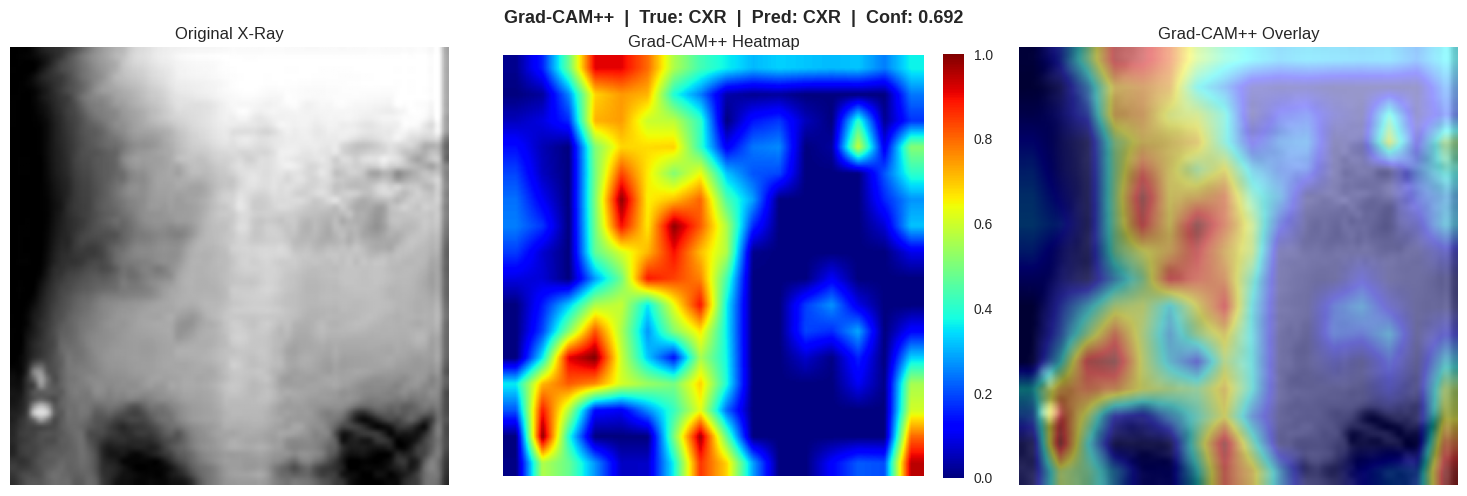


  📁 006143.jpeg
  ✅ True: CXR | 🔮 Pred: CXR | 📈 Conf: 0.637
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_006143.png


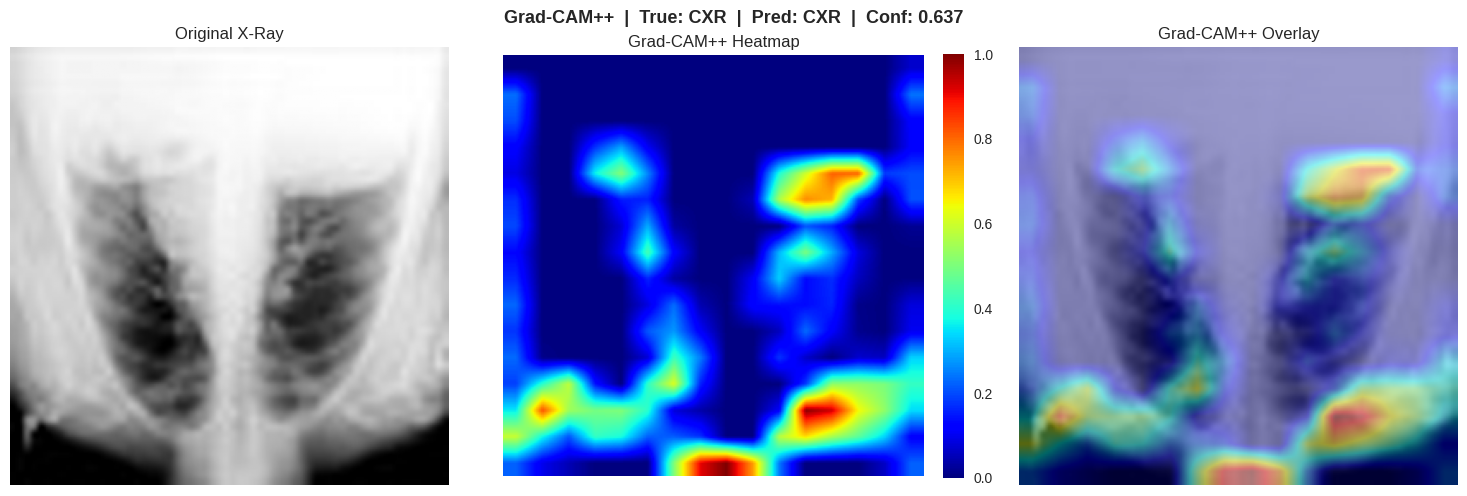


⚠️  No wrong_high_conf cases found

🔍 WRONG_MIDDLE_CONF — 1 examples

  📁 000311.jpeg
  ✅ True: Hand | 🔮 Pred: CXR | 📈 Conf: 0.899
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_000311.png


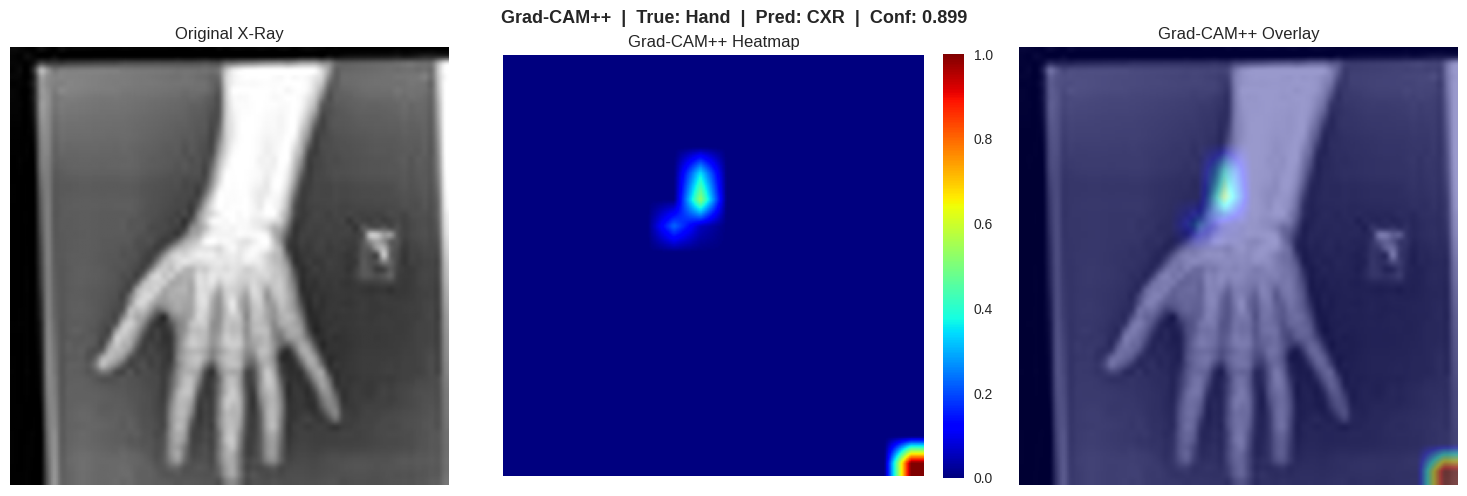


🔍 WRONG_LOW_CONF — 1 examples

  📁 006398.jpeg
  ✅ True: Hand | 🔮 Pred: CXR | 📈 Conf: 0.342
🎯 Target layer: features.16
📐 Using input size: 64x64
✅ Hooks registered on: features.16
💾 Saved: gradcampp_results/gradcampp_006398.png


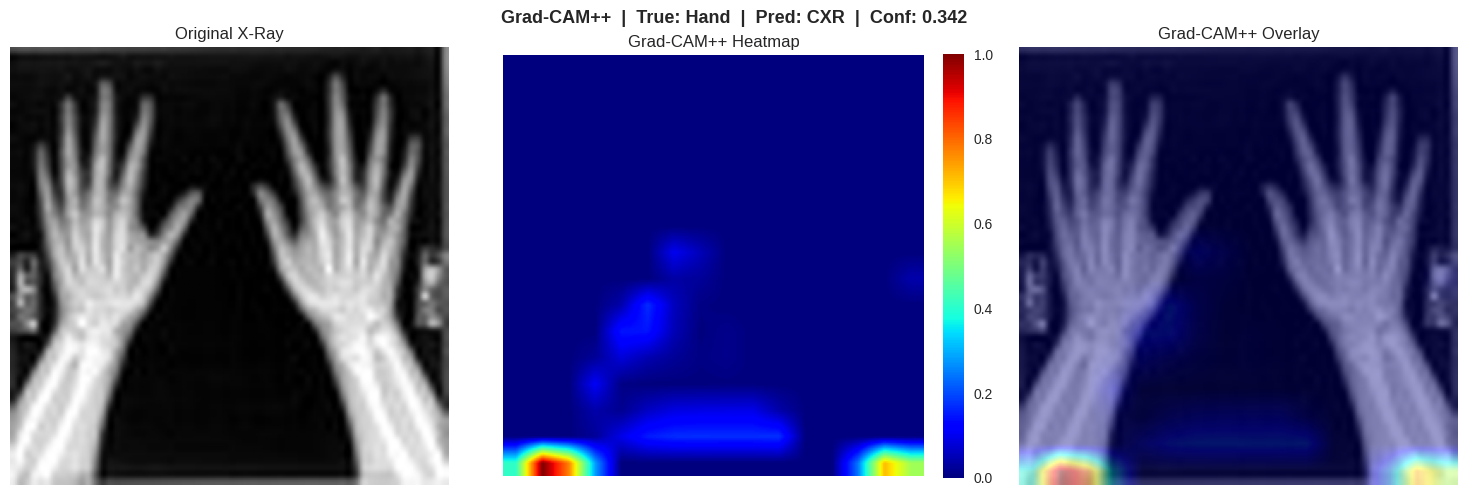


✅ Done. Results saved to: gradcampp_results/


In [71]:
# ============================================================
# ANALYSIS FUNCTION (same structure as your original)
# ============================================================

def analyze_gradcampp_samples(save_dir="gradcampp_results", seed=42):
    print("=" * 60)
    print("GRAD-CAM++ ANALYSIS")
    print("=" * 60)

    np.random.seed(seed)
    os.makedirs(save_dir, exist_ok=True)

    cases_to_analyze = {
        'correct_high_conf':  [],
        'correct_mid_conf':   [],
        'correct_low_conf':   [],
        'wrong_high_conf':    [],
        'wrong_middle_conf':  [],
        'wrong_low_conf':     [],
    }

    for i in range(len(predictions)):
        confidence = np.max(probabilities[i])
        is_correct = predictions[i] == true_labels[i]

        if is_correct:
            if confidence > 0.9:
                cases_to_analyze['correct_high_conf'].append(i)
            elif confidence >= 0.7:
                cases_to_analyze['correct_mid_conf'].append(i)
            else:
                cases_to_analyze['correct_low_conf'].append(i)
        else:
            if confidence > 0.9:
                cases_to_analyze['wrong_high_conf'].append(i)
            elif confidence >= 0.7:
                cases_to_analyze['wrong_middle_conf'].append(i)
            else:
                cases_to_analyze['wrong_low_conf'].append(i)

    print(f"\n📊 Case Distribution:")
    for case_type, indices in cases_to_analyze.items():
        print(f"  {case_type}: {len(indices)} cases")

    model = trained_models[0]
    print(f"\n🧠 Model: {type(model).__name__}")

    for case_type, indices in cases_to_analyze.items():
        if not indices:
            print(f"\n⚠️  No {case_type} cases found")
            continue

        n_samples = min(3, len(indices))
        print(f"\n{'='*50}")
        print(f"🔍 {case_type.upper()} — {n_samples} examples")
        print(f"{'='*50}")

        # ✅ Sort wrong_high_conf by confidence (most dangerous first)
        if case_type == 'wrong_high_conf':
            indices = sorted(indices,
                             key=lambda i: np.max(probabilities[i]),
                             reverse=True)

        sample_indices = np.random.choice(indices, n_samples, replace=False)

        for idx in sample_indices:
            true_label  = class_names[true_labels[idx]]
            pred_label  = class_names[predictions[idx]]
            confidence  = np.max(probabilities[idx])

            print(f"\n  📁 {Path(test_paths[idx]).name}")
            print(f"  ✅ True: {true_label} | 🔮 Pred: {pred_label} | 📈 Conf: {confidence:.3f}")

            fig = create_gradcampp_visualization(
                model, test_paths[idx],
                true_label, pred_label, confidence,
                save_dir=save_dir
            )

            if fig:
                plt.show()
                plt.close(fig)
            else:
                print("  ❌ Visualization failed")

    print(f"\n✅ Done. Results saved to: {save_dir}/")


# ── Run ─────────────────────────────────────────────────────────────────
analyze_gradcampp_samples()

In [72]:
def analyze_gradcam_samples():
    """Generate Grad-CAM visualizations for interesting cases"""
    print("=" * 60)
    print("GRAD-CAM ANALYSIS")
    print("=" * 60)
    
    # Medical imaging modality analysis
    print(f"\n🏥 Medical Imaging Modalities:")
    modality_info = {
        'AbdomenCT': 'Computed Tomography - Abdominal scans',
        'BreastMRI': 'Magnetic Resonance Imaging - Breast tissue',
        'CXR': 'X-Ray - Chest radiography',
        'ChestCT': 'Computed Tomography - Chest scans',
        'Hand': 'X-Ray - Hand radiography',
        'HeadCT': 'Computed Tomography - Head scans'
    }
    
    for class_name, description in modality_info.items():
        class_idx = class_names.index(class_name)
        class_accuracy = np.mean((predictions == true_labels) & (true_labels == class_idx))
        class_total = np.sum(true_labels == class_idx)
        class_correct = np.sum((predictions == true_labels) & (true_labels == class_idx))
        
        print(f"  {class_name:12}: {class_correct}/{class_total} ({class_accuracy*100:.1f}%)")
        print(f"    {description}")
    
    # Imaging technology performance
    print(f"\n📡 Imaging Technology Performance:")
    tech_performance = {
        'CT': [],
        'MRI': [],
        'X-Ray': []
    }
    
    for class_name, description in modality_info.items():
        class_idx = class_names.index(class_name)
        class_accuracy = np.mean((predictions == true_labels) & (true_labels == class_idx))
        
        if 'CT' in class_name:
            tech_performance['CT'].append(class_accuracy)
        elif 'MRI' in class_name:
            tech_performance['MRI'].append(class_accuracy)
        elif 'X-Ray' in class_name or class_name == 'Hand':
            tech_performance['X-Ray'].append(class_accuracy)
    
    for tech, accuracies in tech_performance.items():
        if accuracies:
            avg_acc = np.mean(accuracies)
            print(f"  {tech:6}: {avg_acc*100:.1f}% average accuracy")
    
    # Clinical implications
    print(f"\n⚕️  Clinical Implications:")
    
    # High-confidence wrong predictions (potentially dangerous)
    high_conf_wrong = []
    for i in wrong_indices:
        if np.max(probabilities[i]) > 0.95:
            high_conf_wrong.append(i)
    
    print(f"  High-confidence wrong predictions: {len(high_conf_wrong)}")
    print(f"  These could be clinically significant misdiagnoses")
    
    if high_conf_wrong:
        print(f"  Examples:")
        for idx in high_conf_wrong[:3]:
            true_label = class_names[true_labels[idx]]
            pred_label = class_names[predictions[idx]]
            confidence = np.max(probabilities[idx])
            print(f"    {true_label} → {pred_label} (confidence: {confidence:.3f})")
            
    return tech_performance, high_conf_wrong
            
tech_performance, high_conf_wrong = medical_specific_analysis()

MEDICAL-SPECIFIC ANALYSIS

🏥 Medical Imaging Modalities:
  AbdomenCT   : 2000/2000 (17.0%)
    Computed Tomography - Abdominal scans
  BreastMRI   : 1791/1791 (15.2%)
    Magnetic Resonance Imaging - Breast tissue
  CXR         : 2000/2000 (17.0%)
    X-Ray - Chest radiography
  ChestCT     : 2000/2000 (17.0%)
    Computed Tomography - Chest scans
  Hand        : 1998/2000 (16.9%)
    X-Ray - Hand radiography
  HeadCT      : 2000/2000 (17.0%)
    Computed Tomography - Head scans

📡 Imaging Technology Performance:
  CT    : 17.0% average accuracy
  MRI   : 15.2% average accuracy
  X-Ray : 16.9% average accuracy

⚕️  Clinical Implications:
  High-confidence wrong predictions: 0
  These could be clinically significant misdiagnoses


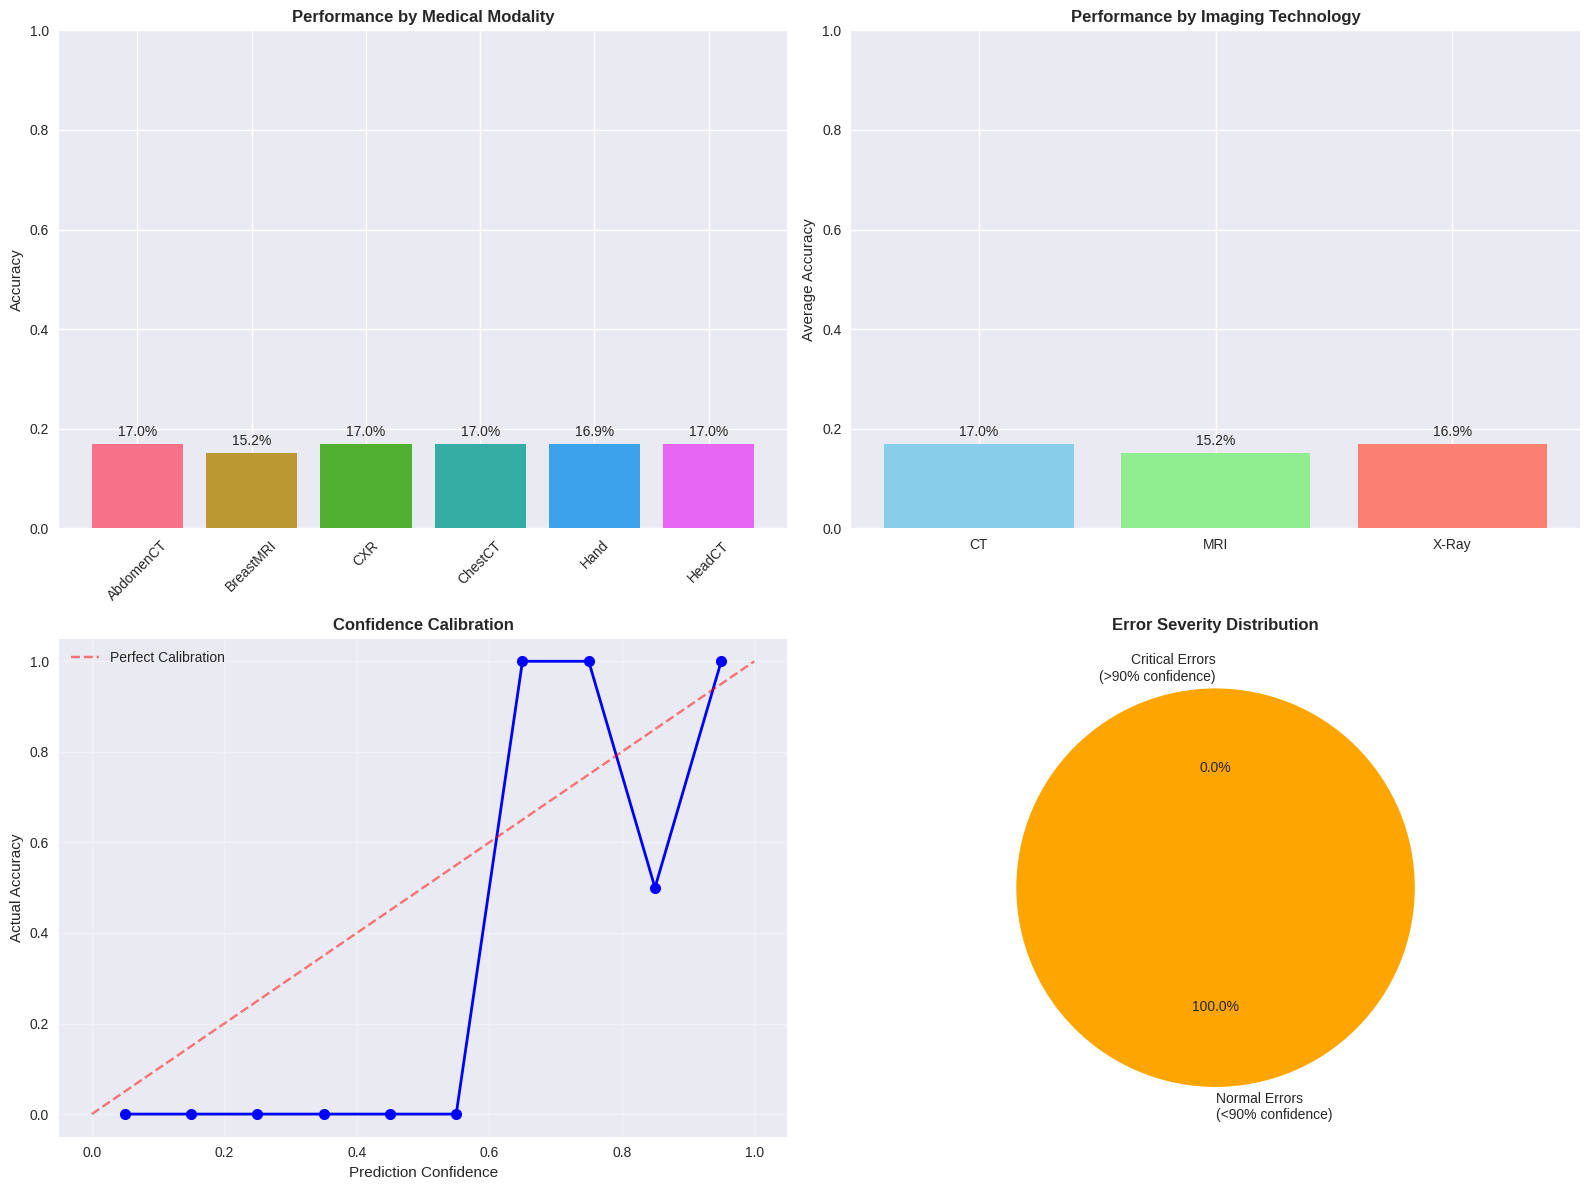

In [73]:
def visualize_medical_analysis():
    """Visualize medical-specific analysis"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Modality performance comparison
    ax1 = axes[0, 0]
    modality_accuracies = []
    for class_name in class_names:
        class_idx = class_names.index(class_name)
        class_accuracy = np.mean((predictions == true_labels) & (true_labels == class_idx))
        modality_accuracies.append(class_accuracy)
    
    bars = ax1.bar(class_names, modality_accuracies, color=sns.color_palette("husl", len(class_names)))
    ax1.set_title('Performance by Medical Modality', fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_ylim(0, 1)
    
    # Add accuracy labels
    for bar, acc in zip(bars, modality_accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc*100:.1f}%', ha='center', va='bottom')
    
    # 2. Imaging technology comparison
    ax2 = axes[0, 1]
    tech_names = []
    tech_accs = []
    
    for tech, accuracies in tech_performance.items():
        if accuracies:
            tech_names.append(tech)
            tech_accs.append(np.mean(accuracies))
    
    bars = ax2.bar(tech_names, tech_accs, color=['skyblue', 'lightgreen', 'salmon'])
    ax2.set_title('Performance by Imaging Technology', fontweight='bold')
    ax2.set_ylabel('Average Accuracy')
    ax2.set_ylim(0, 1)
    
    # Add accuracy labels
    for bar, acc in zip(bars, tech_accs):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc*100:.1f}%', ha='center', va='bottom')
    
    # 3. Confidence vs Accuracy relationship
    ax3 = axes[1, 0]
    confidence_bins = np.linspace(0, 1, 11)
    accuracy_by_confidence = []
    
    for i in range(len(confidence_bins)-1):
        bin_mask = (np.max(probabilities, axis=1) >= confidence_bins[i]) & \
                   (np.max(probabilities, axis=1) < confidence_bins[i+1])
        
        if np.sum(bin_mask) > 0:
            bin_accuracy = np.mean(predictions[bin_mask] == true_labels[bin_mask])
            accuracy_by_confidence.append(bin_accuracy)
        else:
            accuracy_by_confidence.append(0)
    
    bin_centers = (confidence_bins[:-1] + confidence_bins[1:]) / 2
    ax3.plot(bin_centers, accuracy_by_confidence, 'bo-', linewidth=2, markersize=8)
    ax3.set_xlabel('Prediction Confidence')
    ax3.set_ylabel('Actual Accuracy')
    ax3.set_title('Confidence Calibration', fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect Calibration')
    ax3.legend()
    
    # 4. Critical errors analysis
    ax4 = axes[1, 1]
    critical_errors = []
    normal_errors = []
    
    for i in wrong_indices:
        confidence = np.max(probabilities[i])
        if confidence > 0.9:
            critical_errors.append(i)
        else:
            normal_errors.append(i)
    
    labels = ['Critical Errors\n(>90% confidence)', 'Normal Errors\n(<90% confidence)']
    sizes = [len(critical_errors), len(normal_errors)]
    colors = ['red', 'orange']
    
    if sum(sizes) > 0:
        wedges, texts, autotexts = ax4.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                          startangle=90)
        ax4.set_title('Error Severity Distribution', fontweight='bold')
    else:
        ax4.text(0.5, 0.5, 'No errors to analyze', ha='center', va='center', 
                transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Error Severity Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

visualize_medical_analysis()

## 8. Advanced Analysis: t-SNE and Feature Space

FEATURE SPACE ANALYSIS (t-SNE)

🔍 Extracting features from trained model...
Extracted 3264 samples with 512 features

📊 Performing t-SNE dimensionality reduction...


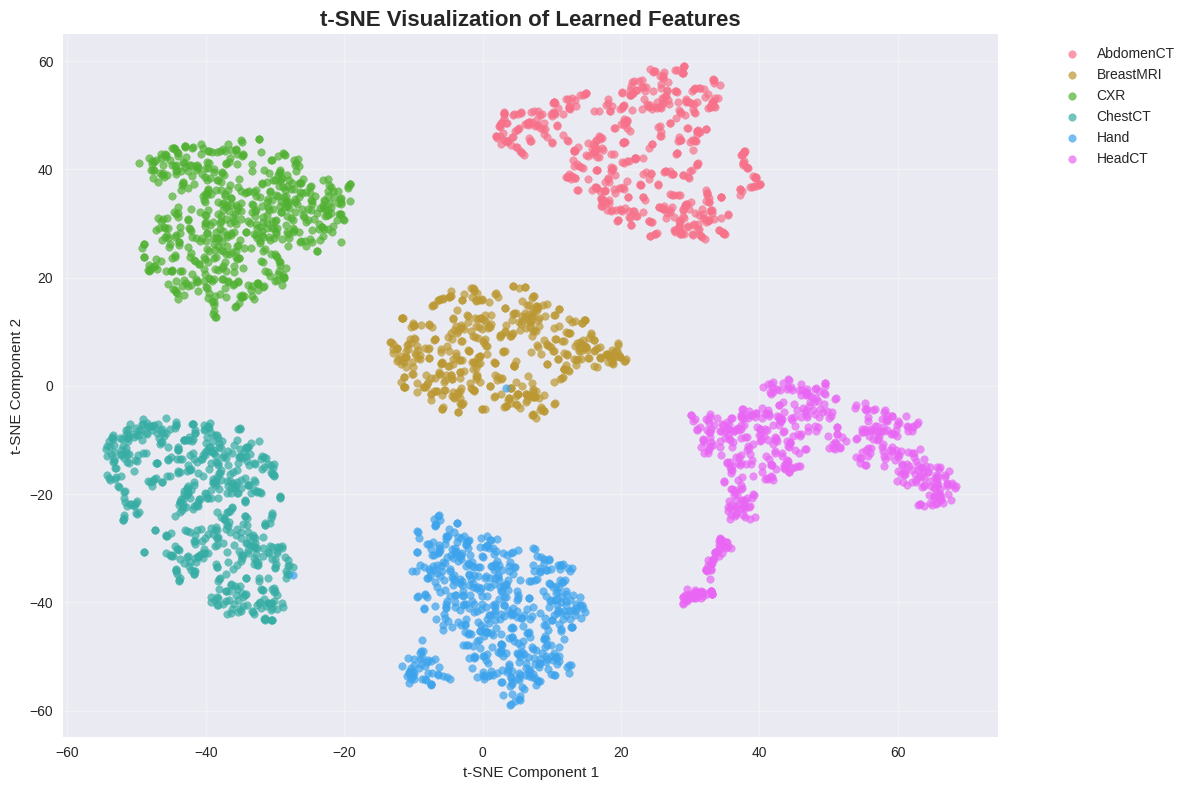


📈 Clustering Analysis:
  Silhouette score: 0.640
  ✅ Good clustering - classes are well separated


In [74]:
def extract_features(model, data_loader, layer_name='classifier.0'):
    """Extract features from a specific layer"""
    features = []
    labels_list = []
    
    # Hook to capture features
    captured_features = []
    
    def hook_fn(module, input, output):
        captured_features.append(output.detach().cpu().numpy())
    
    # Register hook
    for name, module in model.named_modules():
        if name == layer_name:
            module.register_forward_hook(hook_fn)
            break
    
    model.eval()
    with torch.no_grad():
        for batch_idx, (images, batch_labels) in enumerate(data_loader):
            images = images.to(config.device)
            _ = model(images)  # Forward pass to trigger hook
            labels_list.extend(batch_labels.numpy())
            
            # Limit to avoid memory issues
            if batch_idx >= 50:  # Process ~50 batches
                break
    
    if captured_features:
        features = np.vstack(captured_features)
        return features, np.array(labels_list)
    else:
        return None, None

def perform_tsne_analysis():
    """Perform t-SNE analysis on learned features"""
    print("=" * 60)
    print("FEATURE SPACE ANALYSIS (t-SNE)")
    print("=" * 60)
    
    # Extract features
    print("\n🔍 Extracting features from trained model...")
    model = trained_models[0]
    features, feature_labels = extract_features(model, test_loader)
    
    if features is None:
        print("❌ Could not extract features")
        return
    
    print(f"Extracted {features.shape[0]} samples with {features.shape[1]} features")
    
    # Perform t-SNE
    print("\n📊 Performing t-SNE dimensionality reduction...")
    tsne = TSNE(n_components=2, random_state=config.seed, perplexity=30, n_iter=1000)
    tsne_features = tsne.fit_transform(features)
    
    # Visualize
    plt.figure(figsize=(12, 8))
    
    for i, class_name in enumerate(class_names):
        mask = feature_labels == i
        plt.scatter(tsne_features[mask, 0], tsne_features[mask, 1], 
                   label=class_name, alpha=0.7, s=30)
    
    plt.title('t-SNE Visualization of Learned Features', fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Analyze clustering quality
    print(f"\n📈 Clustering Analysis:")
    from sklearn.metrics import silhouette_score
    
    silhouette_avg = silhouette_score(tsne_features, feature_labels)
    print(f"  Silhouette score: {silhouette_avg:.3f}")
    
    if silhouette_avg > 0.5:
        print(f"  ✅ Good clustering - classes are well separated")
    elif silhouette_avg > 0.25:
        print(f"  ⚠️  Moderate clustering - some class overlap")
    else:
        print(f"  ❌ Poor clustering - significant class overlap")
    
    return tsne_features

tsne_results = perform_tsne_analysis()

## 9. Summary and Recommendations

In [75]:
def generate_summary_report():
    """Generate comprehensive summary report"""
    print("=" * 80)
    print("MEDICAL MNIST - COMPREHENSIVE ANALYSIS SUMMARY")
    print("=" * 80)
    
    # Overall performance
    overall_accuracy = np.mean(predictions == true_labels)
    print(f"\n🎯 OVERALL PERFORMANCE:")
    print(f"  Test Accuracy: {overall_accuracy*100:.2f}%")
    print(f"  Total Test Samples: {len(predictions)}")
    print(f"  Correct Predictions: {np.sum(predictions == true_labels)}")
    print(f"  Wrong Predictions: {len(wrong_indices)}")
    
    # Data quality assessment
    print(f"\n📊 DATA QUALITY:")
    print(f"  Dataset Balance: {'Good' if imbalance_ratio < 1.5 else 'Moderate' if imbalance_ratio < 2.0 else 'Poor'}")
    print(f"  Imbalance Ratio: {imbalance_ratio:.2f}:1")
    print(f"  Total Images: {len(image_paths)}")
    print(f"  Classes: {len(class_names)}")
    
    # Model reliability
    print(f"\n🔍 MODEL RELIABILITY:")
    
    # Confidence calibration
    confidences = np.max(probabilities, axis=1)
    avg_confidence = np.mean(confidences)
    confidence_accuracy_correlation = np.corrcoef(confidences, predictions == true_labels)[0, 1]
    
    print(f"  Average Confidence: {avg_confidence:.3f}")
    print(f"  Confidence-Accuracy Correlation: {confidence_accuracy_correlation:.3f}")
    
    if confidence_accuracy_correlation > 0.7:
        print(f"  ✅ Well-calibrated model")
    elif confidence_accuracy_correlation > 0.3:
        print(f"  ⚠️  Moderately calibrated")
    else:
        print(f"  ❌ Poorly calibrated - confidence doesn't match accuracy")
    
    # Critical errors
    critical_errors = len([i for i in wrong_indices if np.max(probabilities[i]) > 0.9])
    print(f"  Critical Errors (>90% confidence): {critical_errors}")
    
    # Per-class performance
    print(f"\n🏥 PER-CLASS PERFORMANCE:")
    worst_classes = []
    best_classes = []
    
    for i, class_name in enumerate(class_names):
        class_mask = true_labels == i
        if np.sum(class_mask) > 0:
            class_accuracy = np.mean(predictions[class_mask] == true_labels[class_mask])
            print(f"  {class_name:12}: {class_accuracy*100:.2f}%")
            
            if class_accuracy < 0.95:
                worst_classes.append((class_name, class_accuracy))
            if class_accuracy > 0.99:
                best_classes.append((class_name, class_accuracy))
    
    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    
    if imbalance_ratio > 1.5:
        print(f"  🔧 Consider class weighting or data augmentation for imbalanced classes")
    
    if critical_errors > 10:
        print(f"  ⚠️  High number of critical errors - review model confidence calibration")
        print(f"      Consider temperature scaling or Platt scaling")
    
    if worst_classes:
        print(f"  🎯 Focus on improving performance for: {[cls for cls, _ in worst_classes]}")
        print(f"      Consider class-specific data augmentation or ensemble methods")
    
    if confidence_accuracy_correlation < 0.5:
        print(f"  📊 Improve confidence calibration using:")
        print(f"      - Temperature scaling")
        print(f"      - Label smoothing")
        print(f"      - Ensemble methods")
    
    print(f"  🏥 Medical-specific considerations:")
    print(f"      - Implement uncertainty quantification for clinical settings")
    print(f"      - Consider cost-sensitive learning for different misdiagnosis types")
    print(f"      - Add attention mechanisms for better interpretability")
    
    return {
        'accuracy': overall_accuracy,
        'imbalance_ratio': imbalance_ratio,
        'critical_errors': critical_errors,
        'confidence_correlation': confidence_accuracy_correlation,
        'worst_classes': worst_classes,
        'best_classes': best_classes
    }

summary_results = generate_summary_report()

MEDICAL MNIST - COMPREHENSIVE ANALYSIS SUMMARY

🎯 OVERALL PERFORMANCE:
  Test Accuracy: 99.98%
  Total Test Samples: 11791
  Correct Predictions: 11789
  Wrong Predictions: 2

📊 DATA QUALITY:
  Dataset Balance: Good
  Imbalance Ratio: 1.12:1
  Total Images: 58954
  Classes: 6

🔍 MODEL RELIABILITY:
  Average Confidence: 1.000
  Confidence-Accuracy Correlation: 0.515
  ⚠️  Moderately calibrated
  Critical Errors (>90% confidence): 0

🏥 PER-CLASS PERFORMANCE:
  AbdomenCT   : 100.00%
  BreastMRI   : 100.00%
  CXR         : 100.00%
  ChestCT     : 100.00%
  Hand        : 99.90%
  HeadCT      : 100.00%

💡 RECOMMENDATIONS:
  🏥 Medical-specific considerations:
      - Implement uncertainty quantification for clinical settings
      - Consider cost-sensitive learning for different misdiagnosis types
      - Add attention mechanisms for better interpretability


In [76]:
def save_analysis_results():
    """Save analysis results to files"""
    print("\n💾 Saving analysis results...")
    
    # Create results directory
    results_dir = Paths.OUTPUTS_DIR / "analysis_results"
    results_dir.mkdir(exist_ok=True)
    
    # Save detailed predictions
    results_df = pd.DataFrame({
        'image_path': [Path(p).name for p in test_paths],
        'true_label': [class_names[i] for i in true_labels],
        'predicted_label': [class_names[i] for i in predictions],
        'confidence': np.max(probabilities, axis=1),
        'is_correct': predictions == true_labels
    })
    
    results_df.to_csv(results_dir / 'detailed_predictions.csv', index=False)
    print(f"  Saved detailed predictions to {results_dir / 'detailed_predictions.csv'}")
    
    # Save wrong predictions analysis
    wrong_df = results_df[~results_df['is_correct']].copy()
    wrong_df.to_csv(results_dir / 'wrong_predictions.csv', index=False)
    print(f"  Saved wrong predictions to {results_dir / 'wrong_predictions.csv'}")
    
    # Save summary statistics
    summary_stats = {
        'total_samples': len(predictions),
        'accuracy': float(np.mean(predictions == true_labels)),
        'total_wrong': int(len(wrong_indices)),
        'critical_errors': int(len([i for i in wrong_indices if np.max(probabilities[i]) > 0.9])),
        'class_distribution': {class_names[i]: int(np.sum(true_labels == i)) for i in range(len(class_names))},
        'per_class_accuracy': {class_names[i]: float(np.mean((predictions == true_labels) & (true_labels == i))) / max(1, np.sum(true_labels == i)) for i in range(len(class_names))}
    }
    
    import json
    with open(results_dir / 'summary_statistics.json', 'w') as f:
        json.dump(summary_stats, f, indent=2)
    
    print(f"  Saved summary statistics to {results_dir / 'summary_statistics.json'}")
    print(f"\n✅ All analysis results saved!")

save_analysis_results()

print("\n" + "=" * 80)
print("🎉 MEDICAL MNIST DEBUGGING & ANALYSIS COMPLETE!")
print("=" * 80)
print("\n📁 Check the analysis_results directory for detailed reports.")
print("🔍 Key insights and recommendations have been provided above.")
print("🏥 Remember: This is medical imaging - always consider clinical implications!")


💾 Saving analysis results...
  Saved detailed predictions to /content/MedicalMNIST/outputs/analysis_results/detailed_predictions.csv
  Saved wrong predictions to /content/MedicalMNIST/outputs/analysis_results/wrong_predictions.csv
  Saved summary statistics to /content/MedicalMNIST/outputs/analysis_results/summary_statistics.json

✅ All analysis results saved!

🎉 MEDICAL MNIST DEBUGGING & ANALYSIS COMPLETE!

📁 Check the analysis_results directory for detailed reports.
🔍 Key insights and recommendations have been provided above.
🏥 Remember: This is medical imaging - always consider clinical implications!
